# SVG-LLM Project Notebook

This notebook contains the full experimental workflow for the SVG language modeling project:
data verification, standard Transformer scaling, µP scaling, generation-focused training, and SVG generation/evaluation.

Large data files and checkpoints are stored in Google Drive, while code is loaded from the GitHub repository.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup and Data Paths

Mount Google Drive and verify that the preprocessed token files are available.  
The large `.bin` token files are stored in Drive instead of GitHub because they are too large to commit.

In [ ]:
!ls -lh /content/drive/MyDrive/svg_lm_project/data/data/tokens

total 346M
-rw------- 1 root root 3.5M Apr 30 04:17 test.bin
-rw------- 1 root root 339M Apr 30 04:17 train.bin
-rw------- 1 root root 3.5M Apr 30 04:17 val.bin


## 2. Clone Repository and Install Dependencies

Clone the project repository into the Colab runtime and install the required Python packages.
All training and evaluation scripts are run from this repository.

In [3]:
%cd /content
!git clone https://github.com/rohitfarfad/svg-llm.git
%cd svg-llm

/content
Cloning into 'svg-llm'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 46 (delta 12), reused 40 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 1.01 MiB | 7.89 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/svg-llm


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 494.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 841.1 kB/s eta 0:00:00


## 3. Dataset Inspection and Report Examples

Load the cleaned SVG training split, compute token lengths using the trained tokenizer, and select representative simple, medium, and complex SVG examples for the report.

In [ ]:
import json
from pathlib import Path

import pandas as pd
from tokenizers import Tokenizer
import cairosvg
from PIL import Image, ImageDraw
from IPython.display import Image as IPyImage, display



REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_JSONL = f"{DRIVE_PROJECT_DIR}/data/cleaned/train.jsonl"
TOKENIZER_PATH = f"{REPO_DIR}/tokenizer/svg_bpe_4096.json"

OUT_DIR = Path(f"{DRIVE_PROJECT_DIR}/report_artifacts/dataset_examples")
SVG_OUT = OUT_DIR / "svg"
PNG_OUT = OUT_DIR / "png"

SVG_OUT.mkdir(parents=True, exist_ok=True)
PNG_OUT.mkdir(parents=True, exist_ok=True)

tokenizer = Tokenizer.from_file(TOKENIZER_PATH)


records = []

with open(TRAIN_JSONL, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        rec = json.loads(line)
        svg = rec["svg"]
        token_len = len(tokenizer.encode(svg).ids)

        records.append({
            "idx": i,
            "id": rec.get("id", f"record_{i}"),
            "source": rec.get("source", "unknown"),
            "svg": svg,
            "char_len": len(svg),
            "token_len": token_len,
        })

df = pd.DataFrame(records)

print("Total records:", len(df))
display(df[["token_len", "char_len"]].describe())



quantile_specs = [
    ("simple", 0.10),
    ("simple", 0.20),
    ("medium", 0.45),
    ("medium", 0.55),
    ("complex", 0.80),
    ("complex", 0.90),
]

chosen_rows = []

used_indices = set()

for label, q in quantile_specs:
    target_len = df["token_len"].quantile(q)

    candidate = (
        df.assign(distance=(df["token_len"] - target_len).abs())
          .sort_values("distance")
    )

    for _, row in candidate.iterrows():
        if row["idx"] not in used_indices:
            chosen_rows.append(row)
            used_indices.add(row["idx"])
            break

examples_df = pd.DataFrame(chosen_rows).reset_index(drop=True)
examples_df["example_name"] = [
    f"{row['complexity']}_{i:02d}"
    for i, row in examples_df.rename(columns={"source": "source"}).iterrows()
] if "complexity" in examples_df.columns else [
    f"{quantile_specs[i][0]}_{i:02d}" for i in range(len(examples_df))
]

examples_df["complexity"] = [x[0] for x in quantile_specs]

display(examples_df[[
    "example_name",
    "complexity",
    "source",
    "token_len",
    "char_len",
]])



def render_svg_to_png(svg_text, png_path):
    cairosvg.svg2png(
        bytestring=svg_text.encode("utf-8"),
        write_to=str(png_path),
        output_width=256,
        output_height=256,
    )


saved_rows = []

for _, row in examples_df.iterrows():
    name = row["example_name"]

    svg_path = SVG_OUT / f"{name}.svg"
    png_path = PNG_OUT / f"{name}.png"

    with open(svg_path, "w", encoding="utf-8") as f:
        f.write(row["svg"])

    try:
        render_svg_to_png(row["svg"], png_path)
        render_ok = True
    except Exception as e:
        render_ok = False
        print("Render failed:", name, e)

    saved_rows.append({
        "example_name": name,
        "complexity": row["complexity"],
        "source": row["source"],
        "token_len": int(row["token_len"]),
        "char_len": int(row["char_len"]),
        "svg_path": str(svg_path),
        "png_path": str(png_path),
        "render_ok": render_ok,
    })

saved_df = pd.DataFrame(saved_rows)
saved_df.to_csv(OUT_DIR / "dataset_examples_summary.csv", index=False)

display(saved_df)
print("Saved summary:", OUT_DIR / "dataset_examples_summary.csv")

Total records: 239586


,token_len,char_len
count,239586.000000,239586.000000
mean,1054.114018,3417.866065
std,831.079408,2913.398279
min,97.000000,230.000000
25%,553.000000,1677.000000
50%,810.000000,2432.000000
75%,1235.000000,3932.000000
max,12582.000000,34179.000000


,example_name,complexity,source,token_len,char_len
0,simple_00,simple,starvector/svg-fonts-simple,354,1069
1,simple_01,simple,starvector/svg-fonts-simple,494,1387
2,medium_02,medium,starvector/svg-fonts-simple,758,2316
3,medium_03,medium,starvector/svg-fonts-simple,867,2530
4,complex_04,complex,starvector/svg-icons-simple,1409,4885
5,complex_05,complex,starvector/svg-fonts-simple,2098,6256


,example_name,complexity,source,token_len,char_len,svg_path,png_path,render_ok
0,simple_00,simple,starvector/svg-fonts-simple,354,1069,/content/drive/MyDrive/svg_lm_project/data/rep...,/content/drive/MyDrive/svg_lm_project/data/rep...,True
1,simple_01,simple,starvector/svg-fonts-simple,494,1387,/content/drive/MyDrive/svg_lm_project/data/rep...,/content/drive/MyDrive/svg_lm_project/data/rep...,True
2,medium_02,medium,starvector/svg-fonts-simple,758,2316,/content/drive/MyDrive/svg_lm_project/data/rep...,/content/drive/MyDrive/svg_lm_project/data/rep...,True
3,medium_03,medium,starvector/svg-fonts-simple,867,2530,/content/drive/MyDrive/svg_lm_project/data/rep...,/content/drive/MyDrive/svg_lm_project/data/rep...,True
4,complex_04,complex,starvector/svg-icons-simple,1409,4885,/content/drive/MyDrive/svg_lm_project/data/rep...,/content/drive/MyDrive/svg_lm_project/data/rep...,True
5,complex_05,complex,starvector/svg-fonts-simple,2098,6256,/content/drive/MyDrive/svg_lm_project/data/rep...,/content/drive/MyDrive/svg_lm_project/data/rep...,True


Saved summary: /content/drive/MyDrive/svg_lm_project/data/report_artifacts/dataset_examples/dataset_examples_summary.csv


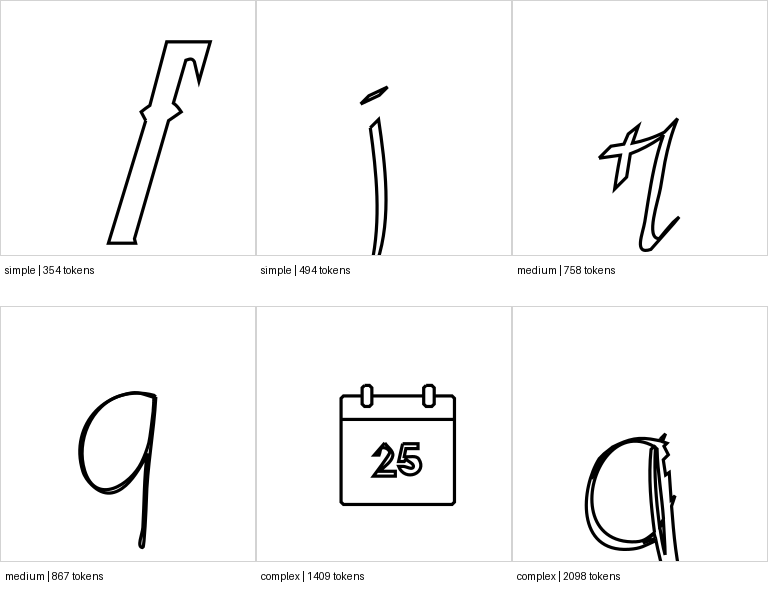

Saved grid: /content/drive/MyDrive/svg_lm_project/data/report_artifacts/dataset_examples/dataset_examples_grid_white_bg.png


In [ ]:
def make_dataset_example_grid(saved_df, out_path, cols=3, cell=256, label_h=50):
    valid_df = saved_df[saved_df["render_ok"]].copy().reset_index(drop=True)

    rows = (len(valid_df) + cols - 1) // cols
    grid = Image.new("RGB", (cols * cell, rows * (cell + label_h)), "white")
    draw = ImageDraw.Draw(grid)

    for i, row in valid_df.iterrows():
        r = i // cols
        c = i % cols

        img = Image.open(row["png_path"]).convert("RGBA").resize((cell, cell))

        # Force white background below transparency.
        bg = Image.new("RGBA", img.size, "white")
        composed = Image.alpha_composite(bg, img).convert("RGB")

        x = c * cell
        y = r * (cell + label_h)

        grid.paste(composed, (x, y))
        draw.rectangle([x, y, x + cell - 1, y + cell - 1], outline="lightgray")

        label = f"{row['complexity']} | {row['token_len']} tokens"
        draw.text((x + 5, y + cell + 8), label, fill="black")

    grid.save(out_path)


grid_path = OUT_DIR / "dataset_examples_grid_white_bg.png"
make_dataset_example_grid(saved_df, grid_path)

display(IPyImage(filename=str(grid_path)))
print("Saved grid:", grid_path)

## 4. Standard Transformer Training: Sanity Check

Run a short Tiny-model training job to verify that the model, tokenizer, data paths, and GPU training loop are working correctly before launching longer experiments.

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/train.bin"
VAL_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/val.bin"
TEST_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/test.bin"

CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"

In [ ]:
import numpy as np

train_data = np.memmap(TRAIN_BIN, dtype=np.uint16, mode="r")
val_data = np.memmap(VAL_BIN, dtype=np.uint16, mode="r")

print("train tokens:", len(train_data))
print("val tokens:", len(val_data))
print("first 20 train token ids:", train_data[:20])

train tokens: 177418221
val tokens: 1834317
first 20 train token ids: [ 31 421 539 266 533 515 534  17  90  22  17 536  18 500  18 421   5 538
 266  19]


In [ ]:
!python train.py \
  --train_bin /content/drive/MyDrive/svg_lm_project/data/data/tokens/train.bin \
  --val_bin /content/drive/MyDrive/svg_lm_project/data/data/tokens/val.bin \
  --out_dir /content/drive/MyDrive/svg_lm_project/checkpoints/tiny_sanity \
  --vocab_size 4096 \
  --block_size 1024 \
  --n_layer 4 \
  --n_head 4 \
  --n_embd 128 \
  --batch_size 16 \
  --max_iters 500 \
  --lr 3e-4 \
  --eval_interval 100 \
  --eval_iters 10 \
  --device cuda

Model config:
GPTConfig(vocab_size=4096, block_size=1024, n_layer=4, n_head=4, n_embd=128, dropout=0.1, bias=True)
Number of parameters: 1,448,704
iter     0 | loss 8.3372 | lr 3.00e-06 | tok/s 89942 | mem 4.10 GB
eval iter     0 | train loss 8.3339 | val loss 8.3313
iter    50 | loss 7.4132 | lr 1.53e-04 | tok/s 37240 | mem 4.12 GB
iter   100 | loss 5.9779 | lr 3.00e-04 | tok/s 315680 | mem 4.12 GB
eval iter   100 | train loss 5.9996 | val loss 6.0041
iter   150 | loss 5.0328 | lr 2.90e-04 | tok/s 270390 | mem 4.12 GB
iter   200 | loss 4.4314 | lr 2.60e-04 | tok/s 315937 | mem 4.12 GB
eval iter   200 | train loss 4.4445 | val loss 4.5464
iter   250 | loss 4.2355 | lr 2.17e-04 | tok/s 270066 | mem 4.12 GB
iter   300 | loss 3.9053 | lr 1.65e-04 | tok/s 315884 | mem 4.12 GB
eval iter   300 | train loss 4.2698 | val loss 4.2777
iter   350 | loss 4.3977 | lr 1.13e-04 | tok/s 271783 | mem 4.12 GB
iter   400 | loss 4.4680 | lr 6.95e-05 | tok/s 316657 | mem 4.12 GB
eval iter   400 | train los

## 5. Standard Parameterization: Learning Rate Sweep

Sweep learning rates on the Tiny model.  
The best learning rate from this sweep is transferred to all larger standard Transformer models for the scaling study.

In [ ]:
#Learning rate sweep

import os
import json
import subprocess
from pathlib import Path

import pandas as pd

REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/train.bin"
VAL_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/val.bin"
TEST_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/test.bin"

CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"


LR_VALUES = [
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
]

# Tiny model config
VOCAB_SIZE = 4096
BLOCK_SIZE = 1024
N_LAYER = 4
N_HEAD = 4
N_EMBD = 128
BATCH_SIZE = 16

# Training config for sweep
MAX_ITERS = 2000
WARMUP_ITERS = 100
EVAL_INTERVAL = 250
EVAL_ITERS = 20
LOG_INTERVAL = 50

FORCE_RERUN = False


# Sanity checks

assert Path(REPO_DIR).exists(), f"Repo not found: {REPO_DIR}"
assert Path(TRAIN_BIN).exists(), f"Train bin not found: {TRAIN_BIN}"
assert Path(VAL_BIN).exists(), f"Val bin not found: {VAL_BIN}"
assert Path(REPO_DIR, "train.py").exists(), f"train.py not found in {REPO_DIR}"

os.chdir(REPO_DIR)

print("Repo:", REPO_DIR)
print("Train:", TRAIN_BIN)
print("Val:", VAL_BIN)
print("Checkpoint dir:", CHECKPOINT_DIR)


def lr_to_name(lr):
    return f"lr_{lr:.0e}".replace("-", "m")


def run_training_for_lr(lr):
    run_name = lr_to_name(lr)
    out_dir = Path(CHECKPOINT_DIR) / "lr_sweep_tiny" / run_name
    summary_path = out_dir / "summary.json"

    if summary_path.exists() and not FORCE_RERUN:
        print(f"\nSkipping {run_name}, summary already exists.")
        return summary_path

    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python", "train.py",
        "--train_bin", TRAIN_BIN,
        "--val_bin", VAL_BIN,
        "--out_dir", str(out_dir),

        "--vocab_size", str(VOCAB_SIZE),
        "--block_size", str(BLOCK_SIZE),
        "--n_layer", str(N_LAYER),
        "--n_head", str(N_HEAD),
        "--n_embd", str(N_EMBD),
        "--batch_size", str(BATCH_SIZE),

        "--max_iters", str(MAX_ITERS),
        "--lr", str(lr),
        "--min_lr", str(lr / 10),
        "--warmup_iters", str(WARMUP_ITERS),
        "--eval_interval", str(EVAL_INTERVAL),
        "--eval_iters", str(EVAL_ITERS),
        "--log_interval", str(LOG_INTERVAL),

        "--device", "cuda",
    ]

    print("\n" + "=" * 80)
    print(f"Running Tiny LR sweep: lr={lr}")
    print("Output:", out_dir)
    print("=" * 80)

    subprocess.run(cmd, check=True)

    return summary_path


def load_summary(summary_path):
    with open(summary_path, "r") as f:
        summary = json.load(f)

    args = summary["args"]

    return {
        "run": summary_path.parent.name,
        "lr": args["lr"],
        "min_lr": args["min_lr"],
        "params": summary["params"],
        "best_val_loss": summary["best_val_loss"],
        "final_train_loss": summary["final_train_loss"],
        "final_val_loss": summary["final_val_loss"],
        "elapsed_sec": summary["elapsed_sec"],
        "tokens_seen": args["max_iters"] * args["batch_size"] * args["block_size"],
        "checkpoint_dir": str(summary_path.parent),
    }



summary_paths = []

for lr in LR_VALUES:
    summary_path = run_training_for_lr(lr)
    summary_paths.append(summary_path)



rows = [load_summary(path) for path in summary_paths]
df = pd.DataFrame(rows)

df = df.sort_values("best_val_loss").reset_index(drop=True)

summary_csv = Path(CHECKPOINT_DIR) / "lr_sweep_tiny" / "lr_sweep_summary.csv"
summary_json = Path(CHECKPOINT_DIR) / "lr_sweep_tiny" / "lr_sweep_summary.json"

df.to_csv(summary_csv, index=False)
df.to_json(summary_json, orient="records", indent=2)

print("\nLearning-rate sweep results:")
display(df)

best = df.iloc[0]

print("\nBest LR:")
print(f"  lr: {best['lr']}")
print(f"  best_val_loss: {best['best_val_loss']:.4f}")
print(f"  checkpoint_dir: {best['checkpoint_dir']}")

print("\nSaved:")
print(" ", summary_csv)
print(" ", summary_json)

Repo: /content/svg-llm
Train: /content/drive/MyDrive/svg_lm_project/data/data/tokens/train.bin
Val: /content/drive/MyDrive/svg_lm_project/data/data/tokens/val.bin
Checkpoint dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints

Running Tiny LR sweep: lr=0.0001
Output: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny/lr_1em04

Running Tiny LR sweep: lr=0.0003
Output: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny/lr_3em04

Running Tiny LR sweep: lr=0.001
Output: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny/lr_1em03

Running Tiny LR sweep: lr=0.003
Output: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny/lr_3em03

Running Tiny LR sweep: lr=0.01
Output: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny/lr_1em02

Learning-rate sweep results:


,run,lr,min_lr,params,best_val_loss,final_train_loss,final_val_loss,elapsed_sec,tokens_seen,checkpoint_dir
0,lr_1em02,0.0100,0.00100,1448704,2.307625,2.298434,2.307625,112.173913,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
1,lr_3em03,0.0030,0.00030,1448704,2.366343,2.357956,2.366343,112.174769,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
2,lr_1em03,0.0010,0.00010,1448704,2.690417,2.692295,2.690417,112.070436,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
3,lr_3em04,0.0003,0.00003,1448704,3.323942,3.334235,3.323942,112.285314,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
4,lr_1em04,0.0001,0.00001,1448704,3.950205,3.971923,3.950205,111.611915,32768000,/content/drive/MyDrive/svg_lm_project/data/che...



Best LR:
  lr: 0.01
  best_val_loss: 2.3076
  checkpoint_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny/lr_1em02

Saved:
  /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny/lr_sweep_summary.csv
  /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny/lr_sweep_summary.json


## 6. Refined Standard Learning Rate Sweep

Run a smaller sweep around the best learning-rate region from the initial sweep.  
This selects the final fixed learning rate used in the standard scaling runs.

In [ ]:
import os
import json
import subprocess
from pathlib import Path

import pandas as pd


# Paths
REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/train.bin"
VAL_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/val.bin"

CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"

os.chdir(REPO_DIR)


# Refined LR sweep around the current best
LR_VALUES = [
    6e-3,
    1e-2,
    2e-2,
    3e-2,
]

# Tiny model config
VOCAB_SIZE = 4096
BLOCK_SIZE = 1024
N_LAYER = 4
N_HEAD = 4
N_EMBD = 128
BATCH_SIZE = 16

# Same sweep length as before
MAX_ITERS = 2000
WARMUP_ITERS = 100
EVAL_INTERVAL = 250
EVAL_ITERS = 20
LOG_INTERVAL = 50

FORCE_RERUN = False


def lr_to_name(lr):
    return f"lr_{lr:.0e}".replace("-", "m")


def run_training_for_lr(lr):
    run_name = lr_to_name(lr)
    out_dir = Path(CHECKPOINT_DIR) / "lr_sweep_tiny_refined" / run_name
    summary_path = out_dir / "summary.json"

    if summary_path.exists() and not FORCE_RERUN:
        print(f"Skipping {run_name}, summary already exists.")
        return summary_path

    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python", "train.py",
        "--train_bin", TRAIN_BIN,
        "--val_bin", VAL_BIN,
        "--out_dir", str(out_dir),

        "--vocab_size", str(VOCAB_SIZE),
        "--block_size", str(BLOCK_SIZE),
        "--n_layer", str(N_LAYER),
        "--n_head", str(N_HEAD),
        "--n_embd", str(N_EMBD),
        "--batch_size", str(BATCH_SIZE),

        "--max_iters", str(MAX_ITERS),
        "--lr", str(lr),
        "--min_lr", str(lr / 10),
        "--warmup_iters", str(WARMUP_ITERS),
        "--eval_interval", str(EVAL_INTERVAL),
        "--eval_iters", str(EVAL_ITERS),
        "--log_interval", str(LOG_INTERVAL),

        "--device", "cuda",
    ]

    print("\n" + "=" * 80)
    print(f"Running refined Tiny LR sweep: lr={lr}")
    print("Output:", out_dir)
    print("=" * 80)

    subprocess.run(cmd, check=True)
    return summary_path


def load_summary(summary_path):
    with open(summary_path, "r") as f:
        summary = json.load(f)

    args = summary["args"]

    return {
        "run": summary_path.parent.name,
        "lr": args["lr"],
        "min_lr": args["min_lr"],
        "params": summary["params"],
        "best_val_loss": summary["best_val_loss"],
        "final_train_loss": summary["final_train_loss"],
        "final_val_loss": summary["final_val_loss"],
        "elapsed_sec": summary["elapsed_sec"],
        "tokens_seen": args["max_iters"] * args["batch_size"] * args["block_size"],
        "checkpoint_dir": str(summary_path.parent),
    }


summary_paths = []

for lr in LR_VALUES:
    try:
        summary_paths.append(run_training_for_lr(lr))
    except subprocess.CalledProcessError:
        print(f"Run failed for lr={lr}. This likely means the LR was unstable.")


rows = [load_summary(path) for path in summary_paths if Path(path).exists()]
df_refined = pd.DataFrame(rows).sort_values("best_val_loss").reset_index(drop=True)

summary_dir = Path(CHECKPOINT_DIR) / "lr_sweep_tiny_refined"
df_refined.to_csv(summary_dir / "lr_sweep_refined_summary.csv", index=False)
df_refined.to_json(summary_dir / "lr_sweep_refined_summary.json", orient="records", indent=2)

display(df_refined)

best = df_refined.iloc[0]

print("\nBest refined LR:")
print(f"  lr: {best['lr']}")
print(f"  best_val_loss: {best['best_val_loss']:.4f}")
print(f"  checkpoint_dir: {best['checkpoint_dir']}")


Running refined Tiny LR sweep: lr=0.006
Output: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny_refined/lr_6em03

Running refined Tiny LR sweep: lr=0.01
Output: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny_refined/lr_1em02

Running refined Tiny LR sweep: lr=0.02
Output: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny_refined/lr_2em02

Running refined Tiny LR sweep: lr=0.03
Output: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny_refined/lr_3em02


,run,lr,min_lr,params,best_val_loss,final_train_loss,final_val_loss,elapsed_sec,tokens_seen,checkpoint_dir
0,lr_6em03,0.006,0.0006,1448704,2.304142,2.293221,2.304142,111.143406,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
1,lr_1em02,0.010,0.0010,1448704,2.307625,2.298434,2.307625,111.500076,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
2,lr_3em02,0.030,0.0030,1448704,2.365486,2.354566,2.365486,111.726527,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
3,lr_2em02,0.020,0.0020,1448704,2.379899,2.369813,2.379899,111.391805,32768000,/content/drive/MyDrive/svg_lm_project/data/che...



Best refined LR:
  lr: 0.006
  best_val_loss: 2.3041
  checkpoint_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/lr_sweep_tiny_refined/lr_6em03


## 7. Standard Transformer Scaling Study

Train multiple decoder-only Transformer models with increasing parameter counts.  
Each model is trained for approximately one epoch over the same tokenized SVG dataset so validation loss can be compared across model sizes.

In [ ]:
import os
import json
import subprocess
from pathlib import Path

import pandas as pd


# -----------------------------
# Paths
# -----------------------------

REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/train.bin"
VAL_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/val.bin"
CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"

os.chdir(REPO_DIR)


# -----------------------------
# Best LR from sweep
# -----------------------------

BEST_LR = 6e-3
MIN_LR = BEST_LR / 10


# -----------------------------
# One epoch settings
# -----------------------------

TRAIN_TOKENS = 177_418_221
BLOCK_SIZE = 1024
BATCH_SIZE = 16
TOKENS_PER_ITER = BLOCK_SIZE * BATCH_SIZE
MAX_ITERS = TRAIN_TOKENS // TOKENS_PER_ITER

print("Tokens per iter:", TOKENS_PER_ITER)
print("Max iters for ~1 epoch:", MAX_ITERS)


# -----------------------------
# Standard scaling model configs
# Keep these MVP-friendly for Colab.
# -----------------------------

MODEL_CONFIGS = [
    {
        "name": "tiny",
        "n_layer": 4,
        "n_head": 4,
        "n_embd": 128,
        "batch_size": 16,
    },
    {
        "name": "small",
        "n_layer": 6,
        "n_head": 6,
        "n_embd": 192,
        "batch_size": 16,
    },
    {
        "name": "medium",
        "n_layer": 6,
        "n_head": 6,
        "n_embd": 384,
        "batch_size": 16,
    },
    {
        "name": "large",
        "n_layer": 8,
        "n_head": 8,
        "n_embd": 512,
        "batch_size": 8,   # safer for Colab memory
    },
    {
        "name": "xl_colab",
        "n_layer": 10,
        "n_head": 10,
        "n_embd": 640,
        "batch_size": 4,   # safer for Colab memory
    },
]


# -----------------------------
# Helpers
# -----------------------------

def run_scaling_model(cfg):
    name = cfg["name"]
    out_dir = Path(CHECKPOINT_DIR) / "scaling_standard" / name
    summary_path = out_dir / "summary.json"

    if summary_path.exists():
        print(f"\nSkipping {name}; summary already exists.")
        return summary_path

    out_dir.mkdir(parents=True, exist_ok=True)

    # Keep approximately one epoch in tokens.
    batch_size = cfg["batch_size"]
    max_iters = TRAIN_TOKENS // (batch_size * BLOCK_SIZE)

    cmd = [
        "python", "train.py",
        "--train_bin", TRAIN_BIN,
        "--val_bin", VAL_BIN,
        "--out_dir", str(out_dir),

        "--vocab_size", "4096",
        "--block_size", str(BLOCK_SIZE),
        "--n_layer", str(cfg["n_layer"]),
        "--n_head", str(cfg["n_head"]),
        "--n_embd", str(cfg["n_embd"]),
        "--batch_size", str(batch_size),

        "--max_iters", str(max_iters),
        "--lr", str(BEST_LR),
        "--min_lr", str(MIN_LR),
        "--warmup_iters", "300",
        "--eval_interval", "1000",
        "--eval_iters", "30",
        "--log_interval", "100",

        "--device", "cuda",
    ]

    print("\n" + "=" * 80)
    print(f"Running standard scaling model: {name}")
    print(f"config: layers={cfg['n_layer']}, heads={cfg['n_head']}, embd={cfg['n_embd']}")
    print(f"batch_size={batch_size}, max_iters={max_iters}")
    print(f"out_dir={out_dir}")
    print("=" * 80)

    subprocess.run(cmd, check=True)
    return summary_path


def load_summary(path):
    with open(path, "r") as f:
        s = json.load(f)

    args = s["args"]

    return {
        "model": path.parent.name,
        "params": s["params"],
        "n_layer": args["n_layer"],
        "n_head": args["n_head"],
        "n_embd": args["n_embd"],
        "block_size": args["block_size"],
        "batch_size": args["batch_size"],
        "max_iters": args["max_iters"],
        "tokens_seen": args["max_iters"] * args["batch_size"] * args["block_size"],
        "lr": args["lr"],
        "best_val_loss": s["best_val_loss"],
        "final_train_loss": s["final_train_loss"],
        "final_val_loss": s["final_val_loss"],
        "elapsed_sec": s["elapsed_sec"],
        "checkpoint_dir": str(path.parent),
    }


# -----------------------------
# Run scaling study
# -----------------------------

summary_paths = []

for cfg in MODEL_CONFIGS:
    try:
        summary_paths.append(run_scaling_model(cfg))
    except subprocess.CalledProcessError:
        print(f"Run failed for model: {cfg['name']}. Try smaller batch_size or smaller model.")


# -----------------------------
# Summarize
# -----------------------------

rows = [load_summary(p) for p in summary_paths if Path(p).exists()]
df_scaling = pd.DataFrame(rows).sort_values("params").reset_index(drop=True)

summary_dir = Path(CHECKPOINT_DIR) / "scaling_standard"
df_scaling.to_csv(summary_dir / "scaling_standard_summary.csv", index=False)
df_scaling.to_json(summary_dir / "scaling_standard_summary.json", orient="records", indent=2)

display(df_scaling)

print("\nSaved:")
print(summary_dir / "scaling_standard_summary.csv")
print(summary_dir / "scaling_standard_summary.json")

Tokens per iter: 16384
Max iters for ~1 epoch: 10828

Skipping tiny; summary already exists.

Skipping small; summary already exists.

Skipping medium; summary already exists.

Skipping large; summary already exists.

Running standard scaling model: xl_colab
config: layers=10, heads=10, embd=640
batch_size=4, max_iters=43314
out_dir=/content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/xl_colab


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
rows = [load_summary(p) for p in summary_paths if Path(p).exists()]
df_scaling = pd.DataFrame(rows).sort_values("params").reset_index(drop=True)

summary_dir = Path(CHECKPOINT_DIR) / "scaling_standard"
df_scaling.to_csv(summary_dir / "scaling_standard_summary.csv", index=False)
df_scaling.to_json(summary_dir / "scaling_standard_summary.json", orient="records", indent=2)

display(df_scaling)

print("\nSaved:")
print(summary_dir / "scaling_standard_summary.csv")
print(summary_dir / "scaling_standard_summary.json")

,model,params,n_layer,n_head,n_embd,block_size,batch_size,max_iters,tokens_seen,lr,best_val_loss,final_train_loss,final_val_loss,elapsed_sec,checkpoint_dir
0,tiny,1448704,4,4,128,1024,16,10828,177405952,0.006,1.753155,1.768231,1.753155,574.427543,/content/drive/MyDrive/svg_lm_project/data/che...
1,small,3652608,6,6,192,1024,16,10828,177405952,0.006,1.364017,1.399892,1.364017,1291.085500,/content/drive/MyDrive/svg_lm_project/data/che...
2,medium,12613632,6,6,384,1024,16,10828,177405952,0.006,1.243755,1.234285,1.251276,1933.893744,/content/drive/MyDrive/svg_lm_project/data/che...
3,large,27841536,8,8,512,1024,8,21657,177414144,0.006,1.298282,1.258571,1.308973,3693.534237,/content/drive/MyDrive/svg_lm_project/data/che...



Saved:
/content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/scaling_standard_summary.csv
/content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/scaling_standard_summary.json


In [ ]:
import os
import re
import json
import subprocess
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm


REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/train.bin"
VAL_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/val.bin"
CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"

os.chdir(REPO_DIR)

BEST_LR = 6e-3
MIN_LR = BEST_LR / 10

TRAIN_TOKENS = 177_418_221
BLOCK_SIZE = 1024

cfg = {
    "name": "medium_plus",
    "n_layer": 8,
    "n_head": 8,
    "n_embd": 448,
    "batch_size": 8,
}

out_dir = Path(CHECKPOINT_DIR) / "scaling_standard" / cfg["name"]
summary_path = out_dir / "summary.json"

batch_size = cfg["batch_size"]
max_iters = TRAIN_TOKENS // (batch_size * BLOCK_SIZE)

print("Model config:", cfg)
print("max_iters:", max_iters)
print("tokens_seen:", max_iters * batch_size * BLOCK_SIZE)
print("out_dir:", out_dir)

if summary_path.exists():
    print("Already done:", summary_path)

else:
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python", "-u", "train.py",   # -u makes logs stream immediately
        "--train_bin", TRAIN_BIN,
        "--val_bin", VAL_BIN,
        "--out_dir", str(out_dir),

        "--vocab_size", "4096",
        "--block_size", str(BLOCK_SIZE),
        "--n_layer", str(cfg["n_layer"]),
        "--n_head", str(cfg["n_head"]),
        "--n_embd", str(cfg["n_embd"]),
        "--batch_size", str(batch_size),

        "--max_iters", str(max_iters),
        "--lr", str(BEST_LR),
        "--min_lr", str(MIN_LR),
        "--warmup_iters", "300",
        "--eval_interval", "1000",
        "--eval_iters", "30",
        "--log_interval", "100",

        "--device", "cuda",
    ]

    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"

    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    step_pattern = re.compile(r"iter\s+(\d+)")
    loss_pattern = re.compile(r"loss\s+([0-9.]+)")
    val_pattern = re.compile(r"val loss\s+([0-9.]+)")
    lr_pattern = re.compile(r"lr\s+([0-9.eE+-]+)")
    mem_pattern = re.compile(r"mem\s+([0-9.]+)\s+GB")

    last_progress = 0

    with tqdm(total=max_iters, desc=f"Training {cfg['name']}", dynamic_ncols=True) as pbar:
        for line in process.stdout:
            line = line.strip()

            # Parse training/eval iteration from train.py logs
            step_match = step_pattern.search(line)
            if step_match:
                step = int(step_match.group(1))
                current_progress = min(step + 1, max_iters)

                if current_progress > last_progress:
                    pbar.update(current_progress - last_progress)
                    last_progress = current_progress

            postfix = {}

            loss_match = loss_pattern.search(line)
            if loss_match:
                postfix["loss"] = loss_match.group(1)

            val_match = val_pattern.search(line)
            if val_match:
                postfix["val"] = val_match.group(1)

            lr_match = lr_pattern.search(line)
            if lr_match:
                postfix["lr"] = lr_match.group(1)

            mem_match = mem_pattern.search(line)
            if mem_match:
                postfix["memGB"] = mem_match.group(1)

            if postfix:
                pbar.set_postfix(postfix)

            # Print important lines only, to keep Colab output clean
            if (
                line.startswith("eval iter")
                or line.startswith("Done.")
                or line.startswith("{")
                or "Number of parameters" in line
                or "Model config" in line
            ):
                print(line)

        process.wait()

        if last_progress < max_iters and process.returncode == 0:
            pbar.update(max_iters - last_progress)

    if process.returncode != 0:
        raise RuntimeError(f"Training failed with exit code {process.returncode}")

    print("\nTraining finished.")

    if summary_path.exists():
        with open(summary_path, "r") as f:
            summary = json.load(f)

        print("\nSummary:")
        print("params:", summary["params"])
        print("best_val_loss:", summary["best_val_loss"])
        print("final_train_loss:", summary["final_train_loss"])
        print("final_val_loss:", summary["final_val_loss"])
        print("elapsed_sec:", summary["elapsed_sec"])
    else:
        print("Warning: training finished but summary.json was not found.")

Model config: {'name': 'medium_plus', 'n_layer': 8, 'n_head': 8, 'n_embd': 448, 'batch_size': 8}
max_iters: 21657
tokens_seen: 177414144
out_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/medium_plus


Training medium_plus:   0%|          | 0/21657 [00:00<?, ?it/s]

Model config:
Number of parameters: 21,608,832
Done.
{

Training finished.

Summary:
params: 21608832
best_val_loss: 1.1639618158340455
final_train_loss: 1.1612287998199462
final_val_loss: 1.1639618158340455
elapsed_sec: 3395.208587408066


In [ ]:
import json
from pathlib import Path
import pandas as pd

scaling_dir = Path(CHECKPOINT_DIR) / "scaling_standard"

rows = []

for summary_path in sorted(scaling_dir.glob("*/summary.json")):
    with open(summary_path) as f:
        s = json.load(f)

    args = s["args"]

    rows.append({
        "model": summary_path.parent.name,
        "params": s["params"],
        "n_layer": args["n_layer"],
        "n_head": args["n_head"],
        "n_embd": args["n_embd"],
        "batch_size": args["batch_size"],
        "max_iters": args["max_iters"],
        "tokens_seen": args["max_iters"] * args["batch_size"] * args["block_size"],
        "lr": args["lr"],
        "best_val_loss": s["best_val_loss"],
        "final_train_loss": s["final_train_loss"],
        "final_val_loss": s["final_val_loss"],
        "elapsed_sec": s["elapsed_sec"],
        "checkpoint_dir": str(summary_path.parent),
    })

df_scaling = pd.DataFrame(rows).sort_values("params").reset_index(drop=True)

df_scaling.to_csv(scaling_dir / "scaling_standard_summary.csv", index=False)
df_scaling.to_json(scaling_dir / "scaling_standard_summary.json", orient="records", indent=2)

display(df_scaling)

,model,params,n_layer,n_head,n_embd,batch_size,max_iters,tokens_seen,lr,best_val_loss,final_train_loss,final_val_loss,elapsed_sec,checkpoint_dir
0,tiny,1448704,4,4,128,16,10828,177405952,0.006,1.753155,1.768231,1.753155,574.427543,/content/drive/MyDrive/svg_lm_project/data/che...
1,small,3652608,6,6,192,16,10828,177405952,0.006,1.364017,1.399892,1.364017,1291.085500,/content/drive/MyDrive/svg_lm_project/data/che...
2,medium,12613632,6,6,384,16,10828,177405952,0.006,1.243755,1.234285,1.251276,1933.893744,/content/drive/MyDrive/svg_lm_project/data/che...
3,medium_plus,21608832,8,8,448,8,21657,177414144,0.006,1.163962,1.161229,1.163962,3395.208587,/content/drive/MyDrive/svg_lm_project/data/che...
4,large,27841536,8,8,512,8,21657,177414144,0.006,1.298282,1.258571,1.308973,3693.534237,/content/drive/MyDrive/svg_lm_project/data/che...


## 8. Standard Scaling Plots and Power-Law Fit

Load the standard scaling summaries, plot validation loss against model size, and fit a power law of the form:

$$
L(N) = aN^{-\alpha} + c
$$

where $N$ is the number of model parameters.

  model     params  step  train_loss  val_loss        lr  elapsed_sec
0  tiny  1448704.0     0    8.308042  8.307091  0.000020     1.560461
1  tiny  1448704.0  1000    2.553742  2.583162  0.005941    54.467366
2  tiny  1448704.0  2000    2.242384  2.263317  0.005660   107.464350
3  tiny  1448704.0  3000    2.154033  2.146903  0.005170   160.331298
4  tiny  1448704.0  4000    2.013571  2.044082  0.004515   213.239231
Loaded models: ['tiny' 'small' 'medium' 'medium_plus' 'large' 'xl_colab']
Saved curve data: /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/training_curves_all_models.csv


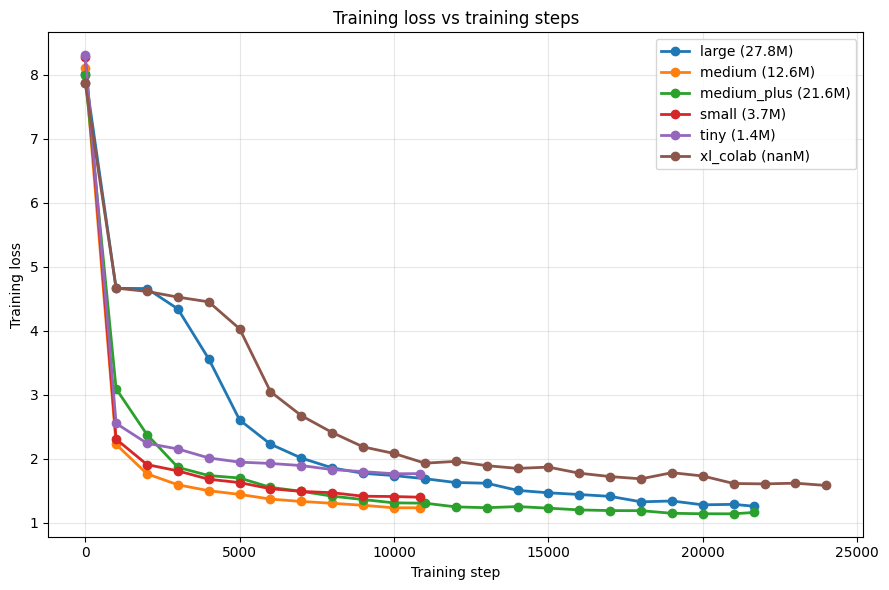

Saved plot: /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/training_loss_vs_steps_all_models.png


In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Paths
# -----------------------------

CHECKPOINT_DIR = "/content/drive/MyDrive/svg_lm_project/data/checkpoints"
SCALING_DIR = Path(CHECKPOINT_DIR) / "scaling_standard"

OUT_PLOT = SCALING_DIR / "training_loss_vs_steps_all_models.png"
OUT_CSV = SCALING_DIR / "training_curves_all_models.csv"


# -----------------------------
# Load metrics
# -----------------------------

rows = []

for model_dir in sorted(SCALING_DIR.glob("*")):
    if not model_dir.is_dir():
        continue

    metrics_path = model_dir / "metrics.jsonl"
    summary_path = model_dir / "summary.json"

    if not metrics_path.exists():
        print("Skipping, no metrics:", model_dir.name)
        continue

    params = None
    if summary_path.exists():
        with open(summary_path, "r") as f:
            summary = json.load(f)
        params = summary.get("params")

    with open(metrics_path, "r") as f:
        for line in f:
            if line.strip():
                rec = json.loads(line)
                rows.append({
                    "model": model_dir.name,
                    "params": params,
                    "step": rec["step"],
                    "train_loss": rec["train_loss"],
                    "val_loss": rec["val_loss"],
                    "lr": rec["lr"],
                    "elapsed_sec": rec["elapsed_sec"],
                })

df_curves = pd.DataFrame(rows)

df_curves = df_curves.sort_values(["params", "step"]).reset_index(drop=True)

print(df_curves.head())
print("Loaded models:", df_curves["model"].unique())

df_curves.to_csv(OUT_CSV, index=False)
print("Saved curve data:", OUT_CSV)


# -----------------------------
# Plot train loss vs steps
# -----------------------------

plt.figure(figsize=(9, 6))

for model_name, group in df_curves.groupby("model"):
    group = group.sort_values("step")
    params = group["params"].iloc[0]

    label = f"{model_name} ({params/1e6:.1f}M)" if params else model_name

    plt.plot(
        group["step"],
        group["train_loss"],
        marker="o",
        linewidth=2,
        label=label,
    )

plt.xlabel("Training step")
plt.ylabel("Training loss")
plt.title("Training loss vs training steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=200)
plt.show()

print("Saved plot:", OUT_PLOT)

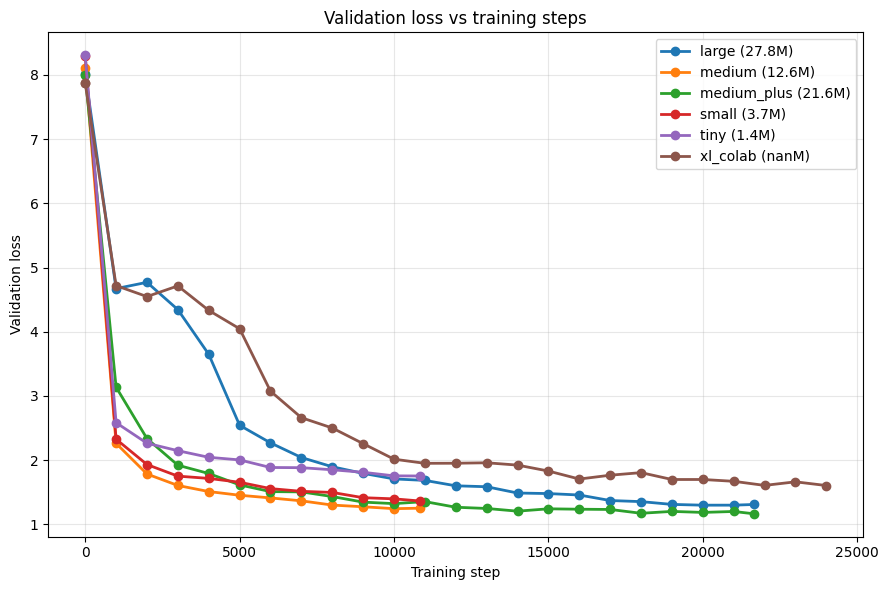

Saved plot: /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/validation_loss_vs_steps_all_models.png


In [ ]:
OUT_VAL_PLOT = SCALING_DIR / "validation_loss_vs_steps_all_models.png"

plt.figure(figsize=(9, 6))

for model_name, group in df_curves.groupby("model"):
    group = group.sort_values("step")
    params = group["params"].iloc[0]

    label = f"{model_name} ({params/1e6:.1f}M)" if params else model_name

    plt.plot(
        group["step"],
        group["val_loss"],
        marker="o",
        linewidth=2,
        label=label,
    )

plt.xlabel("Training step")
plt.ylabel("Validation loss")
plt.title("Validation loss vs training steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_VAL_PLOT, dpi=200)
plt.show()

print("Saved plot:", OUT_VAL_PLOT)

## 9. Training and Validation Loss Curves

Load `metrics.jsonl` from each completed standard model run and plot training/validation loss over training steps.
These plots are used to compare convergence behavior across model sizes.

         model    params  best_val_loss  final_train_loss  final_val_loss  \
0         tiny   1448704       1.753155          1.768231        1.753155   
1        small   3652608       1.364017          1.399892        1.364017   
2       medium  12613632       1.243755          1.234285        1.251276   
3  medium_plus  21608832       1.163962          1.161229        1.163962   
4        large  27841536       1.298282          1.258571        1.308973   

   elapsed_sec  
0   574.427543  
1  1291.085500  
2  1933.893744  
3  3395.208587  
4  3693.534237  


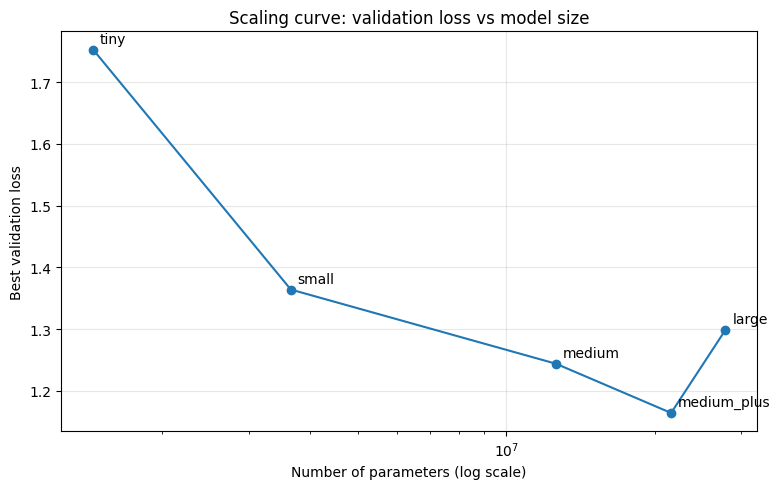

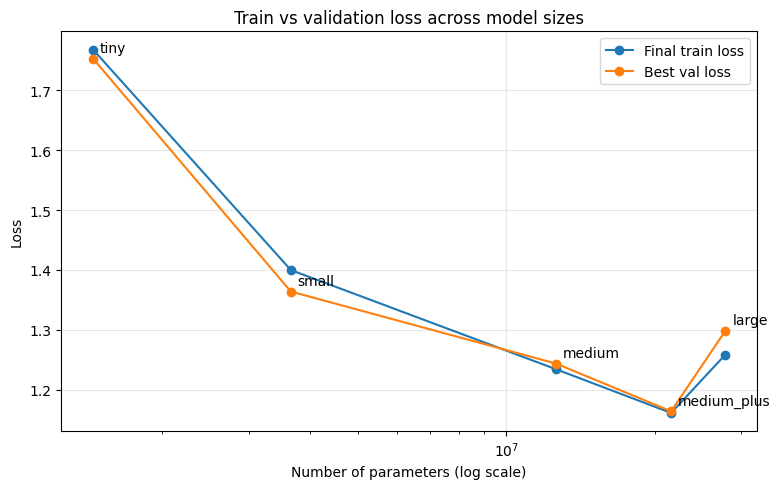

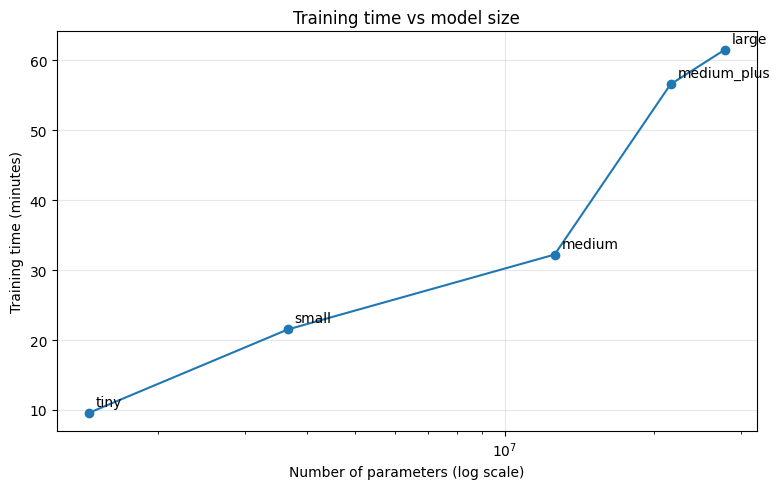


Saved plots:
  /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/scaling_val_loss_vs_params.png
  /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/scaling_train_vs_val.png
  /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/scaling_runtime_vs_params.png


In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

CHECKPOINT_DIR = "/content/drive/MyDrive/svg_lm_project/data/checkpoints"
scaling_dir = Path(CHECKPOINT_DIR) / "scaling_standard"

summary_csv = scaling_dir / "scaling_standard_summary.csv"

# Load results
df = pd.read_csv(summary_csv)
df = df.sort_values("params").reset_index(drop=True)

print(df[["model", "params", "best_val_loss", "final_train_loss", "final_val_loss", "elapsed_sec"]])

df.to_csv(scaling_dir / "scaling_standard_summary_sorted.csv", index=False)

# -------------------------
# Plot 1: Best validation loss vs parameters
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(df["params"], df["best_val_loss"], marker="o")
plt.xscale("log")

for _, row in df.iterrows():
    plt.annotate(
        row["model"],
        (row["params"], row["best_val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.xlabel("Number of parameters (log scale)")
plt.ylabel("Best validation loss")
plt.title("Scaling curve: validation loss vs model size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(scaling_dir / "scaling_val_loss_vs_params.png", dpi=200)
plt.show()



plt.figure(figsize=(8, 5))
plt.plot(df["params"], df["final_train_loss"], marker="o", label="Final train loss")
plt.plot(df["params"], df["best_val_loss"], marker="o", label="Best val loss")
plt.xscale("log")

for _, row in df.iterrows():
    plt.annotate(
        row["model"],
        (row["params"], row["best_val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.xlabel("Number of parameters (log scale)")
plt.ylabel("Loss")
plt.title("Train vs validation loss across model sizes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(scaling_dir / "scaling_train_vs_val.png", dpi=200)
plt.show()



plt.figure(figsize=(8, 5))
plt.plot(df["params"], df["elapsed_sec"] / 60.0, marker="o")
plt.xscale("log")

for _, row in df.iterrows():
    plt.annotate(
        row["model"],
        (row["params"], row["elapsed_sec"] / 60.0),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.xlabel("Number of parameters (log scale)")
plt.ylabel("Training time (minutes)")
plt.title("Training time vs model size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(scaling_dir / "scaling_runtime_vs_params.png", dpi=200)
plt.show()

print("\nSaved plots:")
print(" ", scaling_dir / "scaling_val_loss_vs_params.png")
print(" ", scaling_dir / "scaling_train_vs_val.png")
print(" ", scaling_dir / "scaling_runtime_vs_params.png")

Fitted parameters:
a     = 652220741.444059
alpha = 1.475439
c     = 1.223889


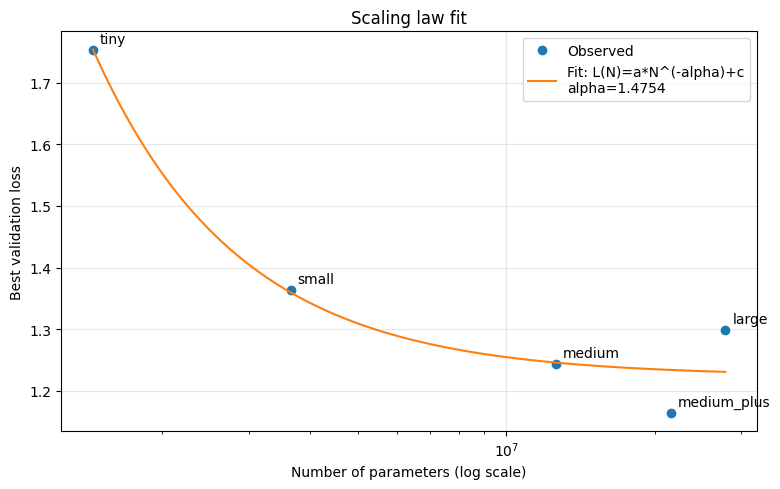


Largest trained model params: 27,841,536
Predicted val loss at 10x params (278,415,360): 1.224115


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

CHECKPOINT_DIR = "/content/drive/MyDrive/svg_lm_project/data/checkpoints"
scaling_dir = Path(CHECKPOINT_DIR) / "scaling_standard"

df = pd.read_csv(scaling_dir / "scaling_standard_summary.csv")
df = df.sort_values("params").reset_index(drop=True)

x = df["params"].values.astype(float)
y = df["best_val_loss"].values.astype(float)

# Power law with offset:
# L(N) = a * N^(-alpha) + c
def power_law(N, a, alpha, c):
    return a * (N ** (-alpha)) + c

# Initial guesses
p0 = [10.0, 0.1, min(y) * 0.9]

params_fit, _ = curve_fit(power_law, x, y, p0=p0, maxfev=20000)
a_hat, alpha_hat, c_hat = params_fit

print("Fitted parameters:")
print(f"a     = {a_hat:.6f}")
print(f"alpha = {alpha_hat:.6f}")
print(f"c     = {c_hat:.6f}")

x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_fit = power_law(x_fit, a_hat, alpha_hat, c_hat)

plt.figure(figsize=(8, 5))
plt.plot(x, y, "o", label="Observed")
plt.plot(x_fit, y_fit, "-", label=f"Fit: L(N)=a*N^(-alpha)+c\nalpha={alpha_hat:.4f}")
plt.xscale("log")

for _, row in df.iterrows():
    plt.annotate(
        row["model"],
        (row["params"], row["best_val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.xlabel("Number of parameters (log scale)")
plt.ylabel("Best validation loss")
plt.title("Scaling law fit")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(scaling_dir / "scaling_powerlaw_fit.png", dpi=200)
plt.show()

# Predict 10x larger than the largest trained model
largest_model = x.max()
pred_10x = power_law(10 * largest_model, a_hat, alpha_hat, c_hat)

print(f"\nLargest trained model params: {largest_model:,.0f}")
print(f"Predicted val loss at 10x params ({10*largest_model:,.0f}): {pred_10x:.6f}")

## 10. µP Setup

Set up the µP implementation using the `mup` package.  
The goal is to test whether a learning rate tuned on a small proxy model transfers better to wider models than in standard parameterization.

In [ ]:
import os
from pathlib import Path

REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/train.bin"
VAL_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/val.bin"
CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"

os.chdir(REPO_DIR)

!PYTHONPATH=/content/svg-llm python train_mup.py \
  --train_bin "$TRAIN_BIN" \
  --val_bin "$VAL_BIN" \
  --out_dir "$CHECKPOINT_DIR/mup_sanity/tiny_width128" \
  --vocab_size 4096 \
  --block_size 1024 \
  --n_layer 6 \
  --n_head 4 \
  --n_embd 128 \
  --batch_size 16 \
  --max_iters 300 \
  --lr 0.003 \
  --min_lr 0.0003 \
  --warmup_iters 50 \
  --eval_interval 100 \
  --eval_iters 10 \
  --device cuda

µP model config:
GPTMuPConfig(vocab_size=4096, block_size=1024, n_layer=6, n_head=4, n_embd=128, dropout=0.1, bias=True)
Number of parameters: 2,369,536
Base width: 128
Delta width: 256
µP train width=128:   0% 0/300 [00:04<?, ?it/s, loss=8.3272, lr=6.00e-05, tok/s=189604, memGB=5.60]eval iter     0 | train loss 8.2106 | val loss 8.2046
µP train width=128:  33% 99/300 [00:16<00:15, 13.29it/s, loss=4.2532, lr=2.74e-03, tok/s=208047, memGB=5.63]eval iter   100 | train loss 4.0424 | val loss 3.9984
µP train width=128:  67% 200/300 [00:24<00:07, 13.25it/s, loss=3.6474, lr=1.23e-03, tok/s=217690, memGB=5.63]eval iter   200 | train loss 3.5650 | val loss 3.7311
µP train width=128:  99% 298/300 [00:33<00:00,  9.87it/s, loss=3.5059, lr=5.58e-04, tok/s=187559, memGB=5.63]eval iter   299 | train loss 3.5271 | val loss 3.4782
µP train width=128: 100% 300/300 [00:34<00:00,  8.76it/s, loss=3.5059, lr=5.58e-04, tok/s=187559, memGB=5.63]

Done.
{
  "params": 2369536,
  "best_val_loss": 3.478230428695

## 11. µP Learning Rate Sweep

Run a learning-rate sweep on the smallest µP proxy model.  
The best µP learning rate is then transferred to all wider µP models without retuning.

In [ ]:
import os
import json
import subprocess
from pathlib import Path

import pandas as pd


REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/train.bin"
VAL_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/val.bin"
CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"

os.chdir(REPO_DIR)


LR_VALUES = [
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    6e-3,
    1e-2,
]

VOCAB_SIZE = 4096
BLOCK_SIZE = 1024

# µP proxy model
N_LAYER = 6
N_HEAD = 4
N_EMBD = 128
BATCH_SIZE = 16

MAX_ITERS = 2000
WARMUP_ITERS = 100
EVAL_INTERVAL = 250
EVAL_ITERS = 20
LOG_INTERVAL = 100

FORCE_RERUN = False


def lr_to_name(lr):
    return f"lr_{lr:.0e}".replace("-", "m")


def run_mup_lr(lr):
    run_name = lr_to_name(lr)
    out_dir = Path(CHECKPOINT_DIR) / "mup_lr_sweep" / run_name
    summary_path = out_dir / "summary.json"

    if summary_path.exists() and not FORCE_RERUN:
        print("Skipping existing:", summary_path)
        return summary_path

    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python", "-u", "train_mup.py",
        "--train_bin", TRAIN_BIN,
        "--val_bin", VAL_BIN,
        "--out_dir", str(out_dir),

        "--vocab_size", str(VOCAB_SIZE),
        "--block_size", str(BLOCK_SIZE),
        "--n_layer", str(N_LAYER),
        "--n_head", str(N_HEAD),
        "--n_embd", str(N_EMBD),
        "--batch_size", str(BATCH_SIZE),

        "--base_width", "128",
        "--delta_width", "256",

        "--max_iters", str(MAX_ITERS),
        "--lr", str(lr),
        "--min_lr", str(lr / 10),
        "--warmup_iters", str(WARMUP_ITERS),
        "--eval_interval", str(EVAL_INTERVAL),
        "--eval_iters", str(EVAL_ITERS),
        "--log_interval", str(LOG_INTERVAL),

        "--device", "cuda",
    ]

    print("\n" + "=" * 80)
    print(f"Running µP LR sweep: lr={lr}")
    print("out_dir:", out_dir)
    print("=" * 80)

    subprocess.run(cmd, check=True)
    return summary_path


def load_summary(path):
    with open(path, "r") as f:
        s = json.load(f)

    args = s["args"]

    return {
        "run": path.parent.name,
        "lr": args["lr"],
        "params": s["params"],
        "best_val_loss": s["best_val_loss"],
        "final_train_loss": s["final_train_loss"],
        "final_val_loss": s["final_val_loss"],
        "elapsed_sec": s["elapsed_sec"],
        "tokens_seen": args["max_iters"] * args["batch_size"] * args["block_size"],
        "checkpoint_dir": str(path.parent),
    }


summary_paths = []

for lr in LR_VALUES:
    try:
        summary_paths.append(run_mup_lr(lr))
    except subprocess.CalledProcessError:
        print("Failed LR:", lr)


rows = [load_summary(p) for p in summary_paths if Path(p).exists()]
df_mup_lr = pd.DataFrame(rows).sort_values("best_val_loss").reset_index(drop=True)

out_root = Path(CHECKPOINT_DIR) / "mup_lr_sweep"
df_mup_lr.to_csv(out_root / "mup_lr_sweep_summary.csv", index=False)
df_mup_lr.to_json(out_root / "mup_lr_sweep_summary.json", orient="records", indent=2)

display(df_mup_lr)

best = df_mup_lr.iloc[0]
print("\nBest µP LR:")
print("lr:", best["lr"])
print("best_val_loss:", best["best_val_loss"])


Running µP LR sweep: lr=0.0001
out_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_lr_sweep/lr_1em04

Running µP LR sweep: lr=0.0003
out_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_lr_sweep/lr_3em04

Running µP LR sweep: lr=0.001
out_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_lr_sweep/lr_1em03

Running µP LR sweep: lr=0.003
out_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_lr_sweep/lr_3em03

Running µP LR sweep: lr=0.006
out_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_lr_sweep/lr_6em03

Running µP LR sweep: lr=0.01
out_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_lr_sweep/lr_1em02


,run,lr,params,best_val_loss,final_train_loss,final_val_loss,elapsed_sec,tokens_seen,checkpoint_dir
0,lr_1em02,0.0100,2369536,2.137234,2.103247,2.202803,161.165118,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
1,lr_6em03,0.0060,2369536,2.165558,2.127094,2.223037,161.091923,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
2,lr_3em03,0.0030,2369536,2.236461,2.205732,2.302212,161.059167,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
3,lr_1em03,0.0010,2369536,2.596954,2.561593,2.656066,160.938793,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
4,lr_3em04,0.0003,2369536,3.225395,3.214131,3.303528,161.163633,32768000,/content/drive/MyDrive/svg_lm_project/data/che...
5,lr_1em04,0.0001,2369536,3.811823,3.808097,3.896497,161.661491,32768000,/content/drive/MyDrive/svg_lm_project/data/che...



Best µP LR:
lr: 0.01
best_val_loss: 2.137233817577362


In [ ]:
BEST_MUP_LR = 0.01

## 12. µP Scaling Study

Train a width-scaled family of µP models using the selected µP learning rate.  
The resulting validation losses are compared against the standard-parameterization scaling curve.

In [4]:
import os
import json
import subprocess
from pathlib import Path

import pandas as pd


REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/train.bin"
VAL_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/val.bin"
CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"

os.chdir(REPO_DIR)


BEST_MUP_LR = 0.01
MIN_MUP_LR = BEST_MUP_LR / 10

TRAIN_TOKENS = 177_418_221
BLOCK_SIZE = 1024


# Width-only µP family.
# Depth fixed for cleaner µP comparison.
MUP_CONFIGS = [
    {"name": "mup_w128", "n_layer": 6, "n_head": 4, "n_embd": 128, "batch_size": 16},
    {"name": "mup_w192", "n_layer": 6, "n_head": 6, "n_embd": 192, "batch_size": 16},
    {"name": "mup_w256", "n_layer": 6, "n_head": 8, "n_embd": 256, "batch_size": 16},
    {"name": "mup_w384", "n_layer": 6, "n_head": 8, "n_embd": 384, "batch_size": 8},
    {"name": "mup_w512", "n_layer": 6, "n_head": 8, "n_embd": 512, "batch_size": 8},
]


def run_mup_model(cfg):
    out_dir = Path(CHECKPOINT_DIR) / "mup_scaling" / cfg["name"]
    summary_path = out_dir / "summary.json"

    if summary_path.exists():
        print("Skipping existing:", summary_path)
        return summary_path

    out_dir.mkdir(parents=True, exist_ok=True)

    batch_size = cfg["batch_size"]
    max_iters = TRAIN_TOKENS // (batch_size * BLOCK_SIZE)

    cmd = [
        "python", "-u", "train_mup.py",
        "--train_bin", TRAIN_BIN,
        "--val_bin", VAL_BIN,
        "--out_dir", str(out_dir),

        "--vocab_size", "4096",
        "--block_size", str(BLOCK_SIZE),
        "--n_layer", str(cfg["n_layer"]),
        "--n_head", str(cfg["n_head"]),
        "--n_embd", str(cfg["n_embd"]),
        "--batch_size", str(batch_size),

        "--base_width", "128",
        "--delta_width", "256",

        "--max_iters", str(max_iters),
        "--lr", str(BEST_MUP_LR),
        "--min_lr", str(MIN_MUP_LR),
        "--warmup_iters", "300",
        "--eval_interval", "1000",
        "--eval_iters", "30",
        "--log_interval", "100",

        "--device", "cuda",
    ]

    print("\n" + "=" * 80)
    print("Running µP scaling:", cfg)
    print("max_iters:", max_iters)
    print("tokens_seen:", max_iters * batch_size * BLOCK_SIZE)
    print("out_dir:", out_dir)
    print("=" * 80)

    subprocess.run(cmd, check=True)
    return summary_path


def load_summary(path):
    with open(path, "r") as f:
        s = json.load(f)

    args = s["args"]

    return {
        "model": path.parent.name,
        "params": s["params"],
        "n_layer": args["n_layer"],
        "n_head": args["n_head"],
        "n_embd": args["n_embd"],
        "batch_size": args["batch_size"],
        "max_iters": args["max_iters"],
        "tokens_seen": args["max_iters"] * args["batch_size"] * args["block_size"],
        "lr": args["lr"],
        "best_val_loss": s["best_val_loss"],
        "final_train_loss": s["final_train_loss"],
        "final_val_loss": s["final_val_loss"],
        "elapsed_sec": s["elapsed_sec"],
        "checkpoint_dir": str(path.parent),
    }


summary_paths = []

for cfg in MUP_CONFIGS:
    try:
        summary_paths.append(run_mup_model(cfg))
    except subprocess.CalledProcessError:
        print("Failed:", cfg["name"])


rows = [load_summary(p) for p in summary_paths if Path(p).exists()]
df_mup_scaling = pd.DataFrame(rows).sort_values("params").reset_index(drop=True)

out_root = Path(CHECKPOINT_DIR) / "mup_scaling"
df_mup_scaling.to_csv(out_root / "mup_scaling_summary.csv", index=False)
df_mup_scaling.to_json(out_root / "mup_scaling_summary.json", orient="records", indent=2)

display(df_mup_scaling)

Skipping existing: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_scaling/mup_w128/summary.json
Skipping existing: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_scaling/mup_w192/summary.json
Skipping existing: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_scaling/mup_w256/summary.json
Skipping existing: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_scaling/mup_w384/summary.json
Skipping existing: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_scaling/mup_w512/summary.json


,model,params,n_layer,n_head,n_embd,batch_size,max_iters,tokens_seen,lr,best_val_loss,final_train_loss,final_val_loss,elapsed_sec,checkpoint_dir
0,mup_w128,2369536,6,4,128,16,10828,177405952,0.01,1.568284,1.547899,1.568284,835.087856,/content/drive/MyDrive/svg_lm_project/data/che...
1,mup_w192,4439040,6,6,192,16,10828,177405952,0.01,1.404406,1.380780,1.404406,1295.034338,/content/drive/MyDrive/svg_lm_project/data/che...
2,mup_w256,7098368,6,8,256,16,10828,177405952,0.01,1.310348,1.322121,1.310348,1741.190341,/content/drive/MyDrive/svg_lm_project/data/che...
3,mup_w384,14186496,6,8,384,8,21657,177414144,0.01,1.404385,1.389111,1.404385,2267.874434,/content/drive/MyDrive/svg_lm_project/data/che...
4,mup_w512,23633920,6,8,512,8,21657,177414144,0.01,1.367967,1.407816,1.367967,2827.410914,/content/drive/MyDrive/svg_lm_project/data/che...


## 13. Standard vs. µP Scaling Comparison

Plot the standard and µP scaling curves on the same axes.  
This compares fixed learning-rate transfer under standard parameterization against learning-rate transfer under µP.

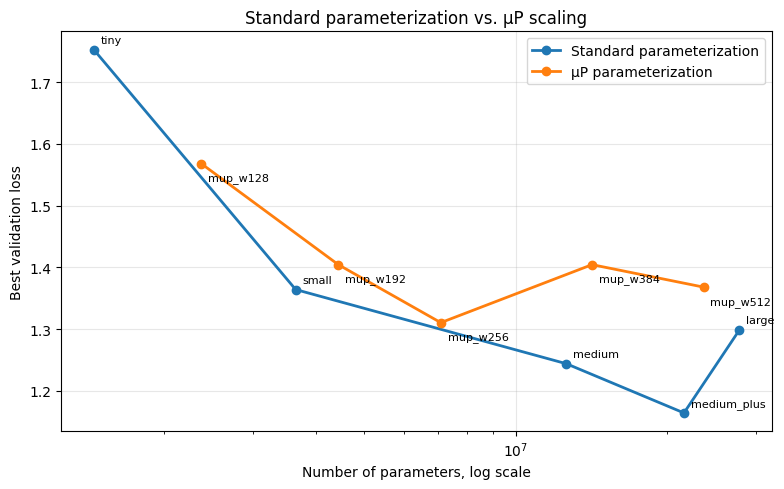

Saved: /content/drive/MyDrive/svg_lm_project/data/checkpoints/mup_scaling/standard_vs_mup_scaling.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CHECKPOINT_DIR = "/content/drive/MyDrive/svg_lm_project/data/checkpoints"

standard_path = Path(CHECKPOINT_DIR) / "scaling_standard" / "scaling_standard_summary.csv"
mup_path = Path(CHECKPOINT_DIR) / "mup_scaling" / "mup_scaling_summary.csv"

df_std = pd.read_csv(standard_path).sort_values("params")
df_mup = pd.read_csv(mup_path).sort_values("params")

out_path = Path(CHECKPOINT_DIR) / "mup_scaling" / "standard_vs_mup_scaling.png"

plt.figure(figsize=(8, 5))

plt.plot(
    df_std["params"],
    df_std["best_val_loss"],
    marker="o",
    linewidth=2,
    label="Standard parameterization",
)

plt.plot(
    df_mup["params"],
    df_mup["best_val_loss"],
    marker="o",
    linewidth=2,
    label="µP parameterization",
)

for _, row in df_std.iterrows():
    plt.annotate(
        row["model"],
        (row["params"], row["best_val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

for _, row in df_mup.iterrows():
    plt.annotate(
        row["model"],
        (row["params"], row["best_val_loss"]),
        textcoords="offset points",
        xytext=(5, -12),
        fontsize=8,
    )

plt.xscale("log")
plt.xlabel("Number of parameters, log scale")
plt.ylabel("Best validation loss")
plt.title("Standard parameterization vs. µP scaling")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

In [ ]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 329 bytes | 329.00 KiB/s, done.
From https://github.com/rohitfarfad/svg-llm
   7ac708d..cec7fec  main       -> origin/main
Updating 7ac708d..cec7fec
Fast-forward
 scripts/generate_eval_svg.py | 2 --
 1 file changed, 2 deletions(-)


In [ ]:
!pip install cairosvg pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 11.0 MB/s eta 0:00:00


## 14. Initial SVG Generation Attempt

Generate SVG samples from the best standard model and evaluate XML validity and render success.
This first attempt is used to diagnose generation failure modes.

In [ ]:
REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

CKPT = f"{DRIVE_PROJECT_DIR}/checkpoints/scaling_standard/medium_plus/best.pt"
TOKENIZER = f"{REPO_DIR}/tokenizer/svg_bpe_4096.json"
TEST_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/test.bin"
OUT_DIR = f"{DRIVE_PROJECT_DIR}/generation/medium_plus"

print("CKPT:", CKPT)
print("TOKENIZER:", TOKENIZER)
print("TEST_BIN:", TEST_BIN)
print("OUT_DIR:", OUT_DIR)

CKPT: /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/medium_plus/best.pt
TOKENIZER: /content/svg-llm/tokenizer/svg_bpe_4096.json
TEST_BIN: /content/drive/MyDrive/svg_lm_project/data/data/tokens/test.bin
OUT_DIR: /content/drive/MyDrive/svg_lm_project/data/generation/medium_plus


In [ ]:
%cd /content/svg-llm

!PYTHONPATH=/content/svg-llm python scripts/generate_eval_svg.py \
  --ckpt "$CKPT" \
  --tokenizer "$TOKENIZER" \
  --test_bin "$TEST_BIN" \
  --out_dir "$OUT_DIR" \
  --device cuda \
  --max_new_tokens 1024 \
  --top_k 50 \
  --top_p 0.95 \
  --eval_batch_size 8

/content/svg-llm
Loaded checkpoint: /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/medium_plus/best.pt
Model config: GPTConfig(vocab_size=4096, block_size=1024, n_layer=8, n_head=8, n_embd=448, dropout=0.1, bias=True)
Best val loss: 1.1639618158340455
Params: 21608832
Evaluating test loss: 100% 219/219 [00:12<00:00, 17.00it/s]
Test loss: 1.1676007775695376
Test perplexity: 3.2142716274345426
Generating samples: 100% 15/15 [01:42<00:00,  6.82s/it]

Generation/evaluation summary:
{
  "checkpoint": "/content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/medium_plus/best.pt",
  "tokenizer": "/content/svg-llm/tokenizer/svg_bpe_4096.json",
  "params": 21608832,
  "checkpoint_best_val_loss": 1.1639618158340455,
  "test_loss": 1.1676007775695376,
  "test_perplexity": 3.2142716274345426,
  "num_samples": 15,
  "xml_valid_rate": 0.0,
  "svg_root_rate": 0.0,
  "render_rate": 0.0,
  "num_unconditional": 10,
  "num_prefix": 5
}

Saved:
SVG samples: /content

In [ ]:
import pandas as pd
from pathlib import Path

OUT_DIR = "/content/drive/MyDrive/svg_lm_project/data/generation/medium_plus"

df = pd.read_csv(f"{OUT_DIR}/generation_metrics.csv")
display(df[[
    "name",
    "kind",
    "temperature",
    "char_len",
    "xml_valid",
    "root_is_svg",
    "render_ok",
    "xml_error",
    "render_error",
]])

# Print first few generated SVG snippets
svg_dir = Path(f"{OUT_DIR}/svg")

for path in sorted(svg_dir.glob("*.svg"))[:5]:
    print("\n" + "=" * 80)
    print(path.name)
    text = path.read_text(encoding="utf-8")
    print(text[:1000])
    print("\n...END...")
    print(text[-500:])

,name,kind,temperature,char_len,xml_valid,root_is_svg,render_ok,xml_error,render_error
0,uncond_00_temp_0.5,unconditional,0.5,4301,False,False,False,"AttValue: ' expected, line 1, column 4302 (<st...",skipped because XML invalid
1,uncond_01_temp_0.5,unconditional,0.5,3098,False,False,False,"AttValue: ' expected, line 1, column 3099 (<st...",skipped because XML invalid
2,uncond_02_temp_0.8,unconditional,0.8,5067,False,False,False,"AttValue: ' expected, line 1, column 5068 (<st...",skipped because XML invalid
3,uncond_03_temp_0.8,unconditional,0.8,3773,False,False,False,"AttValue: ' expected, line 1, column 3774 (<st...",skipped because XML invalid
4,uncond_04_temp_0.8,unconditional,0.8,3438,False,False,False,"AttValue: ' expected, line 1, column 3439 (<st...",skipped because XML invalid
5,uncond_05_temp_1.0,unconditional,1.0,3813,False,False,False,"AttValue: ' expected, line 1, column 3814 (<st...",skipped because XML invalid
6,uncond_06_temp_1.0,unconditional,1.0,3334,False,False,False,"AttValue: ' expected, line 1, column 3335 (<st...",skipped because XML invalid
7,uncond_07_temp_1.0,unconditional,1.0,2385,False,False,False,"Premature end of data in tag svg line 1, line ...",skipped because XML invalid
8,uncond_08_temp_0.7,unconditional,0.7,3534,False,False,False,"AttValue: ' expected, line 1, column 3535 (<st...",skipped because XML invalid
9,uncond_09_temp_0.9,unconditional,0.9,3367,False,False,False,"AttValue: ' expected, line 1, column 3368 (<st...",skipped because XML invalid



prefix_00.svg
<svg viewBox="0 0 24 24" xmlns="http://www.w3.org/2000/svg"><circle cx="12" cy="12" r="10" fill="none" stroke="black"/><circle cx="8" cy="9" r="1.5" fill="black"/><svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M6.768750190734863 3.5625 L9.131250381469727 3.5625 C9.243749618530273 4.125 9.271875381469727 4.6875 9.46875 5.25 L9.46875 9.131250381469727 L7.865624904632568 9.131250381469727 L7.865624904632568 5.925000190734863 L8.203125 5.25 C8.625 4.6875 9.103124618530273 4.125 9.46875 3.5625 L9.46875 3.5625"></path><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M12.421875 3.5625 L12.421875 3.5625 C12.759374618530273 4.125 12.759374618530273 4.6875 13.096875190734863 5.25 L13.096875190734863 9.131250381469727 L12.421875 9.131250381469727 L12.421875 5.25 C12.253125190734863 4.6875 12.084375381469727 4.

In [ ]:
%%writefile /content/svg-llm/scripts/generate_eval_svg_v2.py

import argparse
import json
import math
import sys
from pathlib import Path

ROOT_DIR = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from tokenizers import Tokenizer
from lxml import etree
import cairosvg
from PIL import Image, ImageDraw
import pandas as pd

from model import GPT, GPTConfig


def load_model(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    config = GPTConfig(**ckpt["config"])
    model = GPT(config)
    model.load_state_dict(ckpt["model"])
    model.to(device)
    model.eval()
    return model, config, ckpt


def crop_context(idx, block_size):
    if idx.size(1) > block_size:
        idx = idx[:, -block_size:]
    return idx


def apply_top_k(logits, top_k):
    if top_k is not None and top_k > 0:
        values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
        cutoff = values[:, [-1]]
        logits = logits.clone()
        logits[logits < cutoff] = -float("inf")
    return logits


@torch.no_grad()
def generate(
    model,
    tokenizer,
    prompt,
    device,
    block_size,
    max_new_tokens=2048,
    temperature=0.0,
    top_k=1,
):
    ids = tokenizer.encode(prompt).ids
    eos_id = tokenizer.token_to_id("[EOS]")

    idx = torch.tensor([ids], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        idx_cond = crop_context(idx, block_size)
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]

        if temperature <= 0:
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            logits = apply_top_k(logits, top_k)
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        next_token = int(next_id.item())

        if eos_id is not None and next_token == eos_id:
            break

        idx = torch.cat([idx, next_id], dim=1)

        text = tokenizer.decode(idx[0].tolist(), skip_special_tokens=True)
        if "</svg>" in text:
            break

    text = tokenizer.decode(idx[0].tolist(), skip_special_tokens=True)

    start = text.find("<svg")
    if start != -1:
        text = text[start:]

    if "</svg>" in text:
        text = text[: text.find("</svg>") + len("</svg>")]

    return text.strip()


def validate_xml(svg_text):
    try:
        root = etree.fromstring(svg_text.encode("utf-8"))
        root_is_svg = str(root.tag).lower().endswith("svg")
        return True, root_is_svg, None
    except Exception as e:
        return False, False, str(e)


def render_svg(svg_text, png_path):
    try:
        cairosvg.svg2png(
            bytestring=svg_text.encode("utf-8"),
            write_to=str(png_path),
            output_width=256,
            output_height=256,
        )
        return True, None
    except Exception as e:
        return False, str(e)


def make_placeholder(path, text="invalid"):
    img = Image.new("RGB", (256, 256), "white")
    draw = ImageDraw.Draw(img)
    draw.text((20, 110), text, fill="black")
    img.save(path)


def make_grid(image_paths, labels, out_path, cols=5, cell=256, label_h=32):
    rows = math.ceil(len(image_paths) / cols)
    grid = Image.new("RGB", (cols * cell, rows * (cell + label_h)), "white")
    draw = ImageDraw.Draw(grid)

    for i, img_path in enumerate(image_paths):
        r = i // cols
        c = i % cols

        try:
            img = Image.open(img_path).convert("RGB").resize((cell, cell))
        except Exception:
            img = Image.new("RGB", (cell, cell), "white")

        x = c * cell
        y = r * (cell + label_h)

        grid.paste(img, (x, y))
        draw.text((x + 5, y + cell + 5), labels[i][:35], fill="black")

    grid.save(out_path)


def load_real_prefixes(val_jsonl, tokenizer, num_prefixes=5, prefix_tokens=128):
    prefixes = []

    with open(val_jsonl, "r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            svg = rec["svg"]

            ids = tokenizer.encode(svg).ids
            if len(ids) <= prefix_tokens + 50:
                continue

            prefix_ids = ids[:prefix_tokens]
            prefix = tokenizer.decode(prefix_ids, skip_special_tokens=True)

            if "<svg" in prefix:
                prefixes.append(prefix)

            if len(prefixes) >= num_prefixes:
                break

    return prefixes


@torch.no_grad()
def evaluate_test_loss(model, test_bin, block_size, batch_size, device):
    data = np.memmap(test_bin, dtype=np.uint16, mode="r")

    starts = list(range(0, len(data) - block_size - 1, block_size))
    losses = []
    token_counts = []

    for i in tqdm(range(0, len(starts), batch_size), desc="Evaluating test loss"):
        batch_starts = starts[i : i + batch_size]

        x = torch.stack([
            torch.from_numpy(data[s : s + block_size].astype(np.int64))
            for s in batch_starts
        ]).to(device)

        y = torch.stack([
            torch.from_numpy(data[s + 1 : s + 1 + block_size].astype(np.int64))
            for s in batch_starts
        ]).to(device)

        _, loss = model(x, y)
        losses.append(loss.item())
        token_counts.append(x.numel())

    avg_loss = float(np.average(losses, weights=token_counts))
    return avg_loss, float(math.exp(avg_loss))


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument("--ckpt", required=True)
    parser.add_argument("--tokenizer", required=True)
    parser.add_argument("--test_bin", required=True)
    parser.add_argument("--val_jsonl", required=True)
    parser.add_argument("--out_dir", required=True)

    parser.add_argument("--device", default="cuda")
    parser.add_argument("--max_new_tokens", type=int, default=2048)
    parser.add_argument("--eval_batch_size", type=int, default=8)
    parser.add_argument("--prefix_tokens", type=int, default=128)

    args = parser.parse_args()

    if args.device == "cuda" and not torch.cuda.is_available():
        args.device = "cpu"

    device = torch.device(args.device)

    out_dir = Path(args.out_dir)
    svg_dir = out_dir / "svg"
    png_dir = out_dir / "png"

    svg_dir.mkdir(parents=True, exist_ok=True)
    png_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = Tokenizer.from_file(args.tokenizer)
    model, config, ckpt = load_model(args.ckpt, device)

    print("Loaded checkpoint:", args.ckpt)
    print("Model config:", config)
    print("Best val loss:", ckpt.get("best_val_loss"))
    print("Params:", ckpt.get("params"))

    test_loss, test_ppl = evaluate_test_loss(
        model=model,
        test_bin=args.test_bin,
        block_size=config.block_size,
        batch_size=args.eval_batch_size,
        device=device,
    )

    print("Test loss:", test_loss)
    print("Test perplexity:", test_ppl)

    # More in-distribution unconditional prompts.
    unconditional_prompts = [
        '<svg xmlns="http://www.w3.org/2000/svg"',
        '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0"',
        '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px">',
    ]

    real_prefixes = load_real_prefixes(
        args.val_jsonl,
        tokenizer,
        num_prefixes=5,
        prefix_tokens=args.prefix_tokens,
    )

    sample_specs = []

    # 10 unconditional-ish samples.
    # Mostly greedy/low-temperature because XML is strict.
    temps = [0.0, 0.0, 0.0, 0.2, 0.2, 0.3, 0.3, 0.4, 0.5, 0.6]
    for i, temp in enumerate(temps):
        sample_specs.append({
            "kind": "unconditional",
            "name": f"uncond_{i:02d}_temp_{temp}",
            "prompt": unconditional_prompts[i % len(unconditional_prompts)],
            "temperature": temp,
            "top_k": 10 if temp > 0 else 1,
        })

    # 5 in-distribution real-prefix completions.
    for i, prefix in enumerate(real_prefixes):
        sample_specs.append({
            "kind": "real_prefix",
            "name": f"real_prefix_{i:02d}",
            "prompt": prefix,
            "temperature": 0.0,
            "top_k": 1,
        })

    records = []
    image_paths = []
    labels = []

    for spec in tqdm(sample_specs, desc="Generating samples"):
        text = generate(
            model=model,
            tokenizer=tokenizer,
            prompt=spec["prompt"],
            device=device,
            block_size=config.block_size,
            max_new_tokens=args.max_new_tokens,
            temperature=spec["temperature"],
            top_k=spec["top_k"],
        )

        svg_path = svg_dir / f"{spec['name']}.svg"
        png_path = png_dir / f"{spec['name']}.png"

        with open(svg_path, "w", encoding="utf-8") as f:
            f.write(text)

        xml_valid, root_is_svg, xml_error = validate_xml(text)

        if xml_valid:
            render_ok, render_error = render_svg(text, png_path)
        else:
            render_ok, render_error = False, "skipped because XML invalid"
            make_placeholder(png_path, "invalid XML")

        image_paths.append(png_path)
        labels.append(spec["name"])

        records.append({
            "name": spec["name"],
            "kind": spec["kind"],
            "temperature": spec["temperature"],
            "top_k": spec["top_k"],
            "prompt_len": len(spec["prompt"]),
            "svg_path": str(svg_path),
            "png_path": str(png_path),
            "char_len": len(text),
            "has_closing_svg": "</svg>" in text,
            "xml_valid": xml_valid,
            "root_is_svg": root_is_svg,
            "render_ok": render_ok,
            "xml_error": xml_error,
            "render_error": render_error,
        })

    grid_path = out_dir / "generated_grid.png"
    make_grid(image_paths, labels, grid_path, cols=5)

    df = pd.DataFrame(records)
    df.to_csv(out_dir / "generation_metrics.csv", index=False)
    df.to_json(out_dir / "generation_metrics.json", orient="records", indent=2)

    summary = {
        "checkpoint": args.ckpt,
        "tokenizer": args.tokenizer,
        "params": ckpt.get("params"),
        "checkpoint_best_val_loss": ckpt.get("best_val_loss"),
        "test_loss": test_loss,
        "test_perplexity": test_ppl,
        "num_samples": len(records),
        "xml_valid_rate": float(df["xml_valid"].mean()),
        "svg_root_rate": float(df["root_is_svg"].mean()),
        "render_rate": float(df["render_ok"].mean()),
        "closing_svg_rate": float(df["has_closing_svg"].mean()),
        "num_unconditional": int((df["kind"] == "unconditional").sum()),
        "num_real_prefix": int((df["kind"] == "real_prefix").sum()),
    }

    with open(out_dir / "generation_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print("\nGeneration/evaluation summary:")
    print(json.dumps(summary, indent=2))

    print("\nSaved:")
    print("SVG samples:", svg_dir)
    print("PNG samples:", png_dir)
    print("Grid:", grid_path)
    print("Metrics:", out_dir / "generation_metrics.csv")
    print("Summary:", out_dir / "generation_summary.json")


if __name__ == "__main__":
    main()

Writing /content/svg-llm/scripts/generate_eval_svg_v2.py


In [ ]:
REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

CKPT = f"{DRIVE_PROJECT_DIR}/checkpoints/scaling_standard/medium_plus/best.pt"
TOKENIZER = f"{REPO_DIR}/tokenizer/svg_bpe_4096.json"
TEST_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/test.bin"
VAL_JSONL = f"{DRIVE_PROJECT_DIR}/data/cleaned/val.jsonl"
OUT_DIR_V2 = f"{DRIVE_PROJECT_DIR}/generation/medium_plus_v2"

In [ ]:
%cd /content/svg-llm

!PYTHONPATH=/content/svg-llm python scripts/generate_eval_svg_v2.py \
  --ckpt "$CKPT" \
  --tokenizer "$TOKENIZER" \
  --test_bin "$TEST_BIN" \
  --val_jsonl "$VAL_JSONL" \
  --out_dir "$OUT_DIR_V2" \
  --device cuda \
  --max_new_tokens 2048 \
  --eval_batch_size 8 \
  --prefix_tokens 128

/content/svg-llm
Loaded checkpoint: /content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/medium_plus/best.pt
Model config: GPTConfig(vocab_size=4096, block_size=1024, n_layer=8, n_head=8, n_embd=448, dropout=0.1, bias=True)
Best val loss: 1.1639618158340455
Params: 21608832
Evaluating test loss: 100% 219/219 [00:10<00:00, 20.46it/s]
Test loss: 1.1676007775695376
Test perplexity: 3.2142716274345426
Generating samples: 100% 15/15 [03:05<00:00, 12.39s/it]

Generation/evaluation summary:
{
  "checkpoint": "/content/drive/MyDrive/svg_lm_project/data/checkpoints/scaling_standard/medium_plus/best.pt",
  "tokenizer": "/content/svg-llm/tokenizer/svg_bpe_4096.json",
  "params": 21608832,
  "checkpoint_best_val_loss": 1.1639618158340455,
  "test_loss": 1.1676007775695376,
  "test_perplexity": 3.2142716274345426,
  "num_samples": 15,
  "xml_valid_rate": 0.0,
  "svg_root_rate": 0.0,
  "render_rate": 0.0,
  "closing_svg_rate": 0.0,
  "num_unconditional": 10,
  "num_real_prefix": 5

## 15. Context-Length Experiment

Train/evaluate a model with a larger 2048-token context window to test whether longer context improves SVG structural validity.

In [ ]:
import os
import re
import json
import subprocess
from pathlib import Path

from tqdm.auto import tqdm


REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

TRAIN_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/train.bin"
VAL_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/val.bin"
CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"

os.chdir(REPO_DIR)

TRAIN_TOKENS = 177_418_221

BLOCK_SIZE = 2048
BATCH_SIZE = 4
TOKENS_PER_ITER = BLOCK_SIZE * BATCH_SIZE

FULL_EPOCH_ITERS = TRAIN_TOKENS // TOKENS_PER_ITER
HALF_EPOCH_ITERS = FULL_EPOCH_ITERS // 2

print("tokens_per_iter:", TOKENS_PER_ITER)
print("full_epoch_iters:", FULL_EPOCH_ITERS)
print("half_epoch_iters:", HALF_EPOCH_ITERS)

out_dir = Path(CHECKPOINT_DIR) / "best_model_2048" / "medium_plus_half_epoch"
summary_path = out_dir / "summary.json"

if summary_path.exists():
    print("Already done:", summary_path)

else:
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python", "-u", "train.py",
        "--train_bin", TRAIN_BIN,
        "--val_bin", VAL_BIN,
        "--out_dir", str(out_dir),

        "--vocab_size", "4096",
        "--block_size", str(BLOCK_SIZE),
        "--n_layer", "8",
        "--n_head", "8",
        "--n_embd", "448",
        "--batch_size", str(BATCH_SIZE),

        "--max_iters", str(HALF_EPOCH_ITERS),
        "--lr", "0.003",
        "--min_lr", "0.0003",
        "--warmup_iters", "300",
        "--eval_interval", "1000",
        "--eval_iters", "30",
        "--log_interval", "100",

        "--device", "cuda",
    ]

    print("Running block_size=2048 medium_plus half-epoch")
    print("out_dir:", out_dir)

    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"

    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    step_pattern = re.compile(r"iter\s+(\d+)")
    loss_pattern = re.compile(r"loss\s+([0-9.]+)")
    val_pattern = re.compile(r"val loss\s+([0-9.]+)")
    lr_pattern = re.compile(r"lr\s+([0-9.eE+-]+)")
    mem_pattern = re.compile(r"mem\s+([0-9.]+)\s+GB")
    tok_pattern = re.compile(r"tok/s\s+([0-9.]+)")

    last_progress = 0

    with tqdm(
        total=HALF_EPOCH_ITERS,
        desc="Training medium_plus_2048_half",
        dynamic_ncols=True,
    ) as pbar:
        for line in process.stdout:
            line = line.strip()

            step_match = step_pattern.search(line)
            if step_match:
                step = int(step_match.group(1))
                current_progress = min(step + 1, HALF_EPOCH_ITERS)

                if current_progress > last_progress:
                    pbar.update(current_progress - last_progress)
                    last_progress = current_progress

            postfix = {}

            loss_match = loss_pattern.search(line)
            if loss_match:
                postfix["loss"] = loss_match.group(1)

            val_match = val_pattern.search(line)
            if val_match:
                postfix["val"] = val_match.group(1)

            lr_match = lr_pattern.search(line)
            if lr_match:
                postfix["lr"] = lr_match.group(1)

            mem_match = mem_pattern.search(line)
            if mem_match:
                postfix["memGB"] = mem_match.group(1)

            tok_match = tok_pattern.search(line)
            if tok_match:
                postfix["tok/s"] = tok_match.group(1)

            if postfix:
                pbar.set_postfix(postfix)

            # Keep Colab output readable: print only important lines.
            if (
                line.startswith("Model config")
                or "Number of parameters" in line
                or line.startswith("eval iter")
                or line.startswith("Done.")
                or line.startswith("{")
            ):
                print(line)

        process.wait()

        if process.returncode == 0 and last_progress < HALF_EPOCH_ITERS:
            pbar.update(HALF_EPOCH_ITERS - last_progress)

    if process.returncode != 0:
        raise RuntimeError(f"Training failed with exit code {process.returncode}")

    print("\nTraining finished.")

    if summary_path.exists():
        with open(summary_path, "r") as f:
            summary = json.load(f)

        print("\nSummary:")
        print("params:", summary["params"])
        print("best_val_loss:", summary["best_val_loss"])
        print("final_train_loss:", summary["final_train_loss"])
        print("final_val_loss:", summary["final_val_loss"])
        print("elapsed_sec:", summary["elapsed_sec"])
    else:
        print("Warning: training finished but summary.json was not found.")

tokens_per_iter: 8192
full_epoch_iters: 21657
half_epoch_iters: 10828
Running block_size=2048 medium_plus half-epoch
out_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/best_model_2048/medium_plus_half_epoch


Training medium_plus_2048_half:   0%|          | 0/10828 [00:00<?, ?it/s]

Model config:
Number of parameters: 22,067,584
Done.
{

Training finished.

Summary:
params: 22067584
best_val_loss: 1.4600112318992615
final_train_loss: 1.408171276251475
final_val_loss: 1.4600112318992615
elapsed_sec: 2535.531342983246


In [ ]:
CKPT_2048 = f"{DRIVE_PROJECT_DIR}/checkpoints/best_model_2048/medium_plus_half_epoch/best.pt"
TOKENIZER = f"{REPO_DIR}/tokenizer/svg_bpe_4096.json"
TEST_BIN = f"{DRIVE_PROJECT_DIR}/data/tokens/test.bin"
VAL_JSONL = f"{DRIVE_PROJECT_DIR}/data/cleaned/val.jsonl"
OUT_DIR_2048 = f"{DRIVE_PROJECT_DIR}/generation/medium_plus_2048_half_epoch"

In [ ]:
%cd /content/svg-llm

!PYTHONPATH=/content/svg-llm python scripts/generate_eval_svg_v2.py \
  --ckpt "$CKPT_2048" \
  --tokenizer "$TOKENIZER" \
  --test_bin "$TEST_BIN" \
  --val_jsonl "$VAL_JSONL" \
  --out_dir "$OUT_DIR_2048" \
  --device cuda \
  --max_new_tokens 2048 \
  --eval_batch_size 4 \
  --prefix_tokens 256

/content/svg-llm
Loaded checkpoint: /content/drive/MyDrive/svg_lm_project/data/checkpoints/best_model_2048/medium_plus_half_epoch/best.pt
Model config: GPTConfig(vocab_size=4096, block_size=2048, n_layer=8, n_head=8, n_embd=448, dropout=0.1, bias=True)
Best val loss: 1.4600112318992615
Params: 22067584
Evaluating test loss: 100% 219/219 [00:15<00:00, 13.79it/s]
Test loss: 1.4547948760811542
Test perplexity: 4.2836047056938416
Generating samples: 100% 15/15 [04:40<00:00, 18.71s/it]

Generation/evaluation summary:
{
  "checkpoint": "/content/drive/MyDrive/svg_lm_project/data/checkpoints/best_model_2048/medium_plus_half_epoch/best.pt",
  "tokenizer": "/content/svg-llm/tokenizer/svg_bpe_4096.json",
  "params": 22067584,
  "checkpoint_best_val_loss": 1.4600112318992615,
  "test_loss": 1.4547948760811542,
  "test_perplexity": 4.2836047056938416,
  "num_samples": 15,
  "xml_valid_rate": 0.06666666666666667,
  "svg_root_rate": 0.06666666666666667,
  "render_rate": 0.06666666666666667,
  "closi

{
  "checkpoint": "/content/drive/MyDrive/svg_lm_project/data/checkpoints/best_model_2048/medium_plus_half_epoch/best.pt",
  "tokenizer": "/content/svg-llm/tokenizer/svg_bpe_4096.json",
  "params": 22067584,
  "checkpoint_best_val_loss": 1.4600112318992615,
  "test_loss": 1.4547948760811542,
  "test_perplexity": 4.2836047056938416,
  "num_samples": 15,
  "xml_valid_rate": 0.06666666666666667,
  "svg_root_rate": 0.06666666666666667,
  "render_rate": 0.06666666666666667,
  "closing_svg_rate": 0.06666666666666667,
  "num_unconditional": 10,
  "num_real_prefix": 5
}


,name,kind,temperature,char_len,has_closing_svg,xml_valid,root_is_svg,render_ok,xml_error
0,uncond_00_temp_0.0,unconditional,0.0,7431,False,False,False,False,"AttValue: ' expected, line 1, column 7432 (<st..."
1,uncond_01_temp_0.0,unconditional,0.0,7475,False,False,False,False,"AttValue: ' expected, line 1, column 7476 (<st..."
2,uncond_02_temp_0.0,unconditional,0.0,97,False,False,False,False,"Premature end of data in tag svg line 1, line ..."
3,uncond_03_temp_0.2,unconditional,0.2,9030,False,False,False,False,"Couldn't find end of Start Tag path line 1, li..."
4,uncond_04_temp_0.2,unconditional,0.2,9149,False,False,False,False,Specification mandates value for attribute str...
5,uncond_05_temp_0.3,unconditional,0.3,97,False,False,False,False,"Premature end of data in tag svg line 1, line ..."
6,uncond_06_temp_0.3,unconditional,0.3,9111,False,False,False,False,"AttValue: ' expected, line 1, column 9112 (<st..."
7,uncond_07_temp_0.4,unconditional,0.4,7774,False,False,False,False,"AttValue: ' expected, line 1, column 7775 (<st..."
8,uncond_08_temp_0.5,unconditional,0.5,97,False,False,False,False,"Premature end of data in tag svg line 1, line ..."
9,uncond_09_temp_0.6,unconditional,0.6,6449,False,False,False,False,"AttValue: ' expected, line 1, column 6450 (<st..."


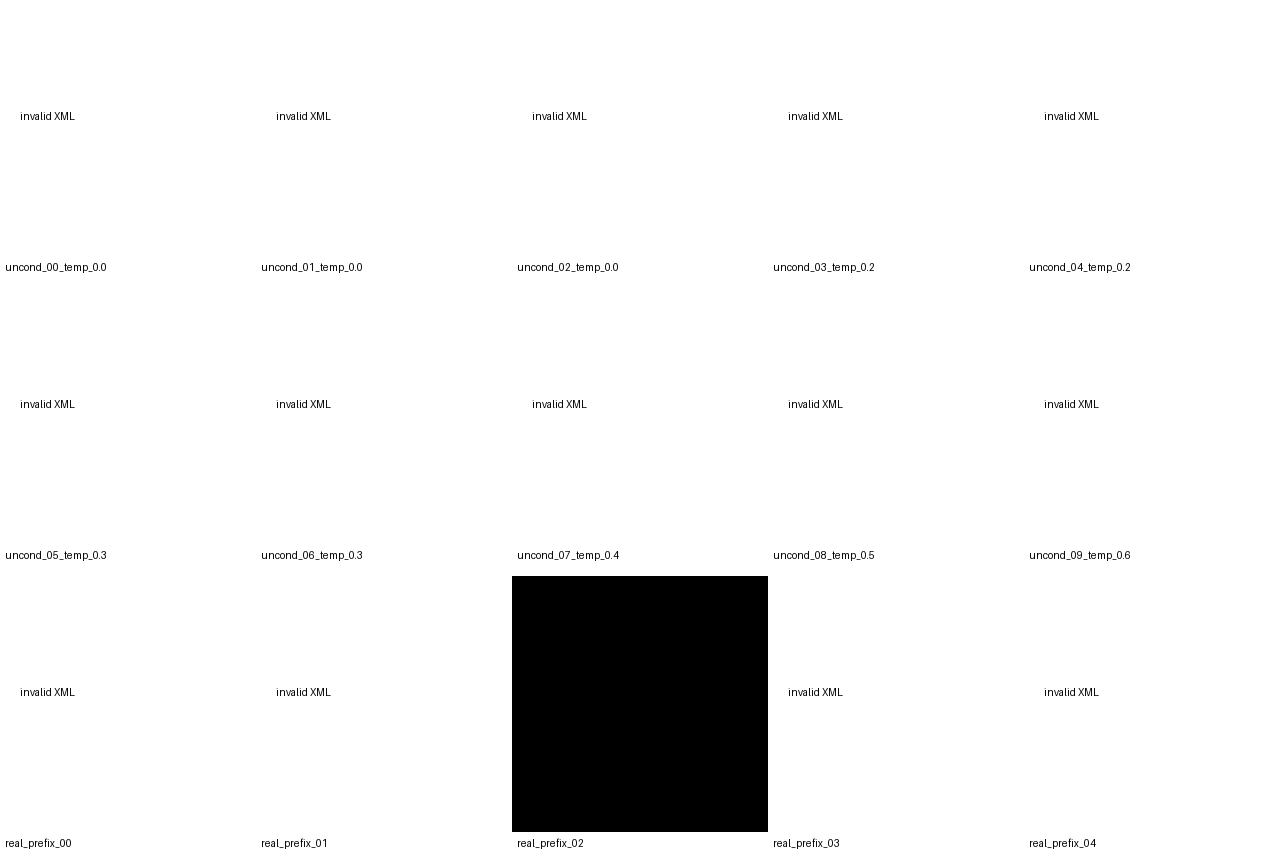

In [ ]:
import json
import pandas as pd
from IPython.display import Image, display

with open(f"{OUT_DIR_2048}/generation_summary.json") as f:
    summary = json.load(f)

print(json.dumps(summary, indent=2))

df_2048 = pd.read_csv(f"{OUT_DIR_2048}/generation_metrics.csv")
display(df_2048[[
    "name",
    "kind",
    "temperature",
    "char_len",
    "has_closing_svg",
    "xml_valid",
    "root_is_svg",
    "render_ok",
    "xml_error",
]])

display(Image(filename=f"{OUT_DIR_2048}/generated_grid.png"))

In [ ]:
!git pull

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.74 KiB | 1.74 MiB/s, done.
From https://github.com/rohitfarfad/svg-llm
   cec7fec..28472b7  main       -> origin/main
Updating cec7fec..28472b7
Fast-forward
 scripts/build_generation_dataset.py | 177 ++++++++++++++++++++++++++++++++++++
 1 file changed, 177 insertions(+)
 create mode 100644 scripts/build_generation_dataset.py


## 16. Generation-Focused Dataset

Build a filtered dataset for generation by keeping shorter SVGs with at most 1024 tokens and requiring successful XML parsing and rendering.
This dataset is intended to make complete valid SVG generation easier.

In [ ]:
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

%cd /content/svg-llm

!PYTHONPATH=/content/svg-llm python scripts/build_generation_dataset.py \
  --input_data_dir /content/drive/MyDrive/svg_lm_project/data/data \
  --output_data_dir /content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024 \
  --tokenizer /content/svg-llm/tokenizer/svg_bpe_4096.json \
  --max_tokens 1024 \
  --target_train_tokens 105000000 \
  --target_val_tokens 1000000 \
  --target_test_tokens 1000000

/content/svg-llm
Filtering train.jsonl: 100% 239586/239586 [12:36<00:00, 316.72it/s]
Filtering val.jsonl:  99% 2409/2444 [00:09<00:00, 262.51it/s]
Filtering test.jsonl:  96% 2357/2446 [00:08<00:00, 283.24it/s]
{
  "train": {
    "input": "/content/drive/MyDrive/svg_lm_project/data/data/cleaned/train.jsonl",
    "output_jsonl": "/content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/cleaned/train.jsonl",
    "output_bin": "/content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/tokens/train.bin",
    "max_tokens": 1024,
    "target_tokens": 105000000,
    "check_render": true,
    "kept_records": 157469,
    "total_tokens_with_eos": 98155882,
    "stats": {
      "too_long": 82117,
      "kept": 157469
    }
  },
  "val": {
    "input": "/content/drive/MyDrive/svg_lm_project/data/data/cleaned/val.jsonl",
    "output_jsonl": "/content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/cleaned/val.jsonl",
    "output_bin": "/content/drive/MyDrive/svg_lm_proje

## 17. Generation-Focused Model Training

Train the Medium Plus model on the filtered 1024-token render-valid dataset.
This model is used as the final checkpoint for SVG generation.

In [ ]:
import os
import re
import json
import subprocess
from pathlib import Path

from tqdm.auto import tqdm


# -----------------------------
# Paths
# -----------------------------

REPO_DIR = "/content/svg-llm"

# Change this if your filtered dataset folder has a different name
GEN_DATA_DIR = "/content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024"

TRAIN_BIN = f"{GEN_DATA_DIR}/tokens/train.bin"
VAL_BIN = f"{GEN_DATA_DIR}/tokens/val.bin"

CHECKPOINT_DIR = "/content/drive/MyDrive/svg_lm_project/data/checkpoints"
OUT_DIR = f"{CHECKPOINT_DIR}/generation_1024/medium_plus"

os.chdir(REPO_DIR)


# -----------------------------
# Training setup
# -----------------------------

TRAIN_TOKENS = 98_000_000

BLOCK_SIZE = 1024
BATCH_SIZE = 16

TOKENS_PER_ITER = BLOCK_SIZE * BATCH_SIZE
MAX_ITERS = TRAIN_TOKENS // TOKENS_PER_ITER

print("train_bin:", TRAIN_BIN)
print("val_bin:", VAL_BIN)
print("out_dir:", OUT_DIR)
print("tokens_per_iter:", TOKENS_PER_ITER)
print("max_iters:", MAX_ITERS)
print("tokens_seen:", MAX_ITERS * TOKENS_PER_ITER)


# -----------------------------
# Model config: medium_plus
# -----------------------------

N_LAYER = 8
N_HEAD = 8
N_EMBD = 448

LR = 0.003
MIN_LR = LR / 10


# -----------------------------
# Check files
# -----------------------------

assert Path(TRAIN_BIN).exists(), f"Missing train bin: {TRAIN_BIN}"
assert Path(VAL_BIN).exists(), f"Missing val bin: {VAL_BIN}"
assert Path("train.py").exists(), "train.py not found. Make sure REPO_DIR is correct."
assert Path("model.py").exists(), "model.py not found. Make sure REPO_DIR is correct."

out_dir = Path(OUT_DIR)
summary_path = out_dir / "summary.json"

if summary_path.exists():
    print("Already trained. Found summary:", summary_path)

else:
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python", "-u", "train.py",

        "--train_bin", TRAIN_BIN,
        "--val_bin", VAL_BIN,
        "--out_dir", OUT_DIR,

        "--vocab_size", "4096",
        "--block_size", str(BLOCK_SIZE),
        "--n_layer", str(N_LAYER),
        "--n_head", str(N_HEAD),
        "--n_embd", str(N_EMBD),
        "--batch_size", str(BATCH_SIZE),

        "--max_iters", str(MAX_ITERS),
        "--lr", str(LR),
        "--min_lr", str(MIN_LR),
        "--warmup_iters", "300",
        "--weight_decay", "0.1",
        "--grad_clip", "1.0",

        "--eval_interval", "1000",
        "--eval_iters", "30",
        "--log_interval", "100",

        "--device", "cuda",
    ]

    print("\nRunning generation-focused training:")
    print(" ".join(cmd))

    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"

    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    step_pattern = re.compile(r"iter\s+(\d+)")
    loss_pattern = re.compile(r"loss\s+([0-9.]+)")
    val_pattern = re.compile(r"val loss\s+([0-9.]+)")
    train_eval_pattern = re.compile(r"train loss\s+([0-9.]+)")
    lr_pattern = re.compile(r"lr\s+([0-9.eE+-]+)")
    mem_pattern = re.compile(r"mem\s+([0-9.]+)\s+GB")
    tok_pattern = re.compile(r"tok/s\s+([0-9.]+)")

    last_progress = 0

    with tqdm(
        total=MAX_ITERS,
        desc="Training generation_1024 medium_plus",
        dynamic_ncols=True,
    ) as pbar:
        for line in process.stdout:
            line = line.strip()

            step_match = step_pattern.search(line)
            if step_match:
                step = int(step_match.group(1))
                current_progress = min(step + 1, MAX_ITERS)

                if current_progress > last_progress:
                    pbar.update(current_progress - last_progress)
                    last_progress = current_progress

            postfix = {}

            loss_match = loss_pattern.search(line)
            if loss_match:
                postfix["loss"] = loss_match.group(1)

            train_eval_match = train_eval_pattern.search(line)
            if train_eval_match:
                postfix["train"] = train_eval_match.group(1)

            val_match = val_pattern.search(line)
            if val_match:
                postfix["val"] = val_match.group(1)

            lr_match = lr_pattern.search(line)
            if lr_match:
                postfix["lr"] = lr_match.group(1)

            mem_match = mem_pattern.search(line)
            if mem_match:
                postfix["memGB"] = mem_match.group(1)

            tok_match = tok_pattern.search(line)
            if tok_match:
                postfix["tok/s"] = tok_match.group(1)

            if postfix:
                pbar.set_postfix(postfix)

            # Keep output readable
            if (
                line.startswith("Model config")
                or "Number of parameters" in line
                or line.startswith("eval iter")
                or line.startswith("Done.")
                or line.startswith("{")
            ):
                print(line)

        process.wait()

        if process.returncode == 0 and last_progress < MAX_ITERS:
            pbar.update(MAX_ITERS - last_progress)

    if process.returncode != 0:
        raise RuntimeError(f"Training failed with exit code {process.returncode}")

    print("\nTraining finished.")

    if summary_path.exists():
        with open(summary_path, "r") as f:
            summary = json.load(f)

        print("\nSummary:")
        print(json.dumps(summary, indent=2))
    else:
        print("Warning: training finished but summary.json was not found.")

train_bin: /content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/tokens/train.bin
val_bin: /content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/tokens/val.bin
out_dir: /content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus
tokens_per_iter: 16384
max_iters: 5981
tokens_seen: 97992704

Running generation-focused training:
python -u train.py --train_bin /content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/tokens/train.bin --val_bin /content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/tokens/val.bin --out_dir /content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus --vocab_size 4096 --block_size 1024 --n_layer 8 --n_head 8 --n_embd 448 --batch_size 16 --max_iters 5981 --lr 0.003 --min_lr 0.00030000000000000003 --warmup_iters 300 --weight_decay 0.1 --grad_clip 1.0 --eval_interval 1000 --eval_iters 30 --log_interval 100 --device cuda


Training generation_1024 medium_plus:   0%|          | 0/5981 [00:00<?, ?it/s]

Model config:
Number of parameters: 21,608,832
Done.
{

Training finished.

Summary:
{
  "params": 21608832,
  "best_val_loss": 1.2538903951644897,
  "final_train_loss": 1.254187289873759,
  "final_val_loss": 1.2538903951644897,
  "elapsed_sec": 1819.7851159572601,
  "args": {
    "train_bin": "/content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/tokens/train.bin",
    "val_bin": "/content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/tokens/val.bin",
    "out_dir": "/content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus",
    "vocab_size": 4096,
    "block_size": 1024,
    "n_layer": 8,
    "n_head": 8,
    "n_embd": 448,
    "dropout": 0.1,
    "batch_size": 16,
    "max_iters": 5981,
    "lr": 0.003,
    "min_lr": 0.00030000000000000003,
    "warmup_iters": 300,
    "weight_decay": 0.1,
    "grad_clip": 1.0,
    "eval_interval": 1000,
    "eval_iters": 30,
    "log_interval": 100,
    "device": "cuda",
    "seed": 42
  }
}


In [ ]:
REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

CKPT_GEN_1024 = f"{DRIVE_PROJECT_DIR}/checkpoints/generation_1024/medium_plus/best.pt"
TOKENIZER = f"{REPO_DIR}/tokenizer/svg_bpe_4096.json"
TEST_BIN_GEN_1024 = f"{DRIVE_PROJECT_DIR}/generation_dataset_1024/tokens/test.bin"
VAL_JSONL_GEN_1024 = f"{DRIVE_PROJECT_DIR}/generation_dataset_1024/cleaned/val.jsonl"
OUT_DIR_GEN_1024 = f"{DRIVE_PROJECT_DIR}/generation/medium_plus_generation_1024"

print("CKPT:", CKPT_GEN_1024)
print("TOKENIZER:", TOKENIZER)
print("TEST_BIN:", TEST_BIN_GEN_1024)
print("VAL_JSONL:", VAL_JSONL_GEN_1024)
print("OUT_DIR:", OUT_DIR_GEN_1024)

CKPT: /content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus/best.pt
TOKENIZER: /content/svg-llm/tokenizer/svg_bpe_4096.json
TEST_BIN: /content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/tokens/test.bin
VAL_JSONL: /content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/cleaned/val.jsonl
OUT_DIR: /content/drive/MyDrive/svg_lm_project/data/generation/medium_plus_generation_1024


In [ ]:
%cd /content/svg-llm

!PYTHONPATH=/content/svg-llm python scripts/generate_eval_svg_v2.py \
  --ckpt "$CKPT_GEN_1024" \
  --tokenizer "$TOKENIZER" \
  --test_bin "$TEST_BIN_GEN_1024" \
  --val_jsonl "$VAL_JSONL_GEN_1024" \
  --out_dir "$OUT_DIR_GEN_1024" \
  --device cuda \
  --max_new_tokens 1024 \
  --eval_batch_size 8 \
  --prefix_tokens 256

/content/svg-llm
Loaded checkpoint: /content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus/best.pt
Model config: GPTConfig(vocab_size=4096, block_size=1024, n_layer=8, n_head=8, n_embd=448, dropout=0.1, bias=True)
Best val loss: 1.2538903951644897
Params: 21608832
Evaluating test loss: 100% 122/122 [00:06<00:00, 20.09it/s]
Test loss: 1.2644603311038407
Test perplexity: 3.5411811550199186
Generating samples: 100% 15/15 [01:19<00:00,  5.30s/it]

Generation/evaluation summary:
{
  "checkpoint": "/content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus/best.pt",
  "tokenizer": "/content/svg-llm/tokenizer/svg_bpe_4096.json",
  "params": 21608832,
  "checkpoint_best_val_loss": 1.2538903951644897,
  "test_loss": 1.2644603311038407,
  "test_perplexity": 3.5411811550199186,
  "num_samples": 15,
  "xml_valid_rate": 0.06666666666666667,
  "svg_root_rate": 0.06666666666666667,
  "render_rate": 0.06666666666666667,
  "closing_svg_rate": 0.066666

{
  "checkpoint": "/content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus/best.pt",
  "tokenizer": "/content/svg-llm/tokenizer/svg_bpe_4096.json",
  "params": 21608832,
  "checkpoint_best_val_loss": 1.2538903951644897,
  "test_loss": 1.2644603311038407,
  "test_perplexity": 3.5411811550199186,
  "num_samples": 15,
  "xml_valid_rate": 0.06666666666666667,
  "svg_root_rate": 0.06666666666666667,
  "render_rate": 0.06666666666666667,
  "closing_svg_rate": 0.06666666666666667,
  "num_unconditional": 10,
  "num_real_prefix": 5
}


,name,kind,temperature,char_len,has_closing_svg,xml_valid,root_is_svg,render_ok,xml_error
0,uncond_00_temp_0.0,unconditional,0.0,3351,False,False,False,False,"AttValue: ' expected, line 1, column 3352 (<st..."
1,uncond_01_temp_0.0,unconditional,0.0,3399,False,False,False,False,"AttValue: ' expected, line 1, column 3400 (<st..."
2,uncond_02_temp_0.0,unconditional,0.0,97,False,False,False,False,"Premature end of data in tag svg line 1, line ..."
3,uncond_03_temp_0.2,unconditional,0.2,3648,False,False,False,False,"AttValue: ' expected, line 1, column 3649 (<st..."
4,uncond_04_temp_0.2,unconditional,0.2,3369,False,False,False,False,"AttValue: ' expected, line 1, column 3370 (<st..."
5,uncond_05_temp_0.3,unconditional,0.3,97,False,False,False,False,"Premature end of data in tag svg line 1, line ..."
6,uncond_06_temp_0.3,unconditional,0.3,3363,False,False,False,False,"AttValue: ' expected, line 1, column 3364 (<st..."
7,uncond_07_temp_0.4,unconditional,0.4,4517,False,False,False,False,"AttValue: ' expected, line 1, column 4518 (<st..."
8,uncond_08_temp_0.5,unconditional,0.5,97,False,False,False,False,"Premature end of data in tag svg line 1, line ..."
9,uncond_09_temp_0.6,unconditional,0.6,4848,False,False,False,False,"AttValue: ' expected, line 1, column 4849 (<st..."


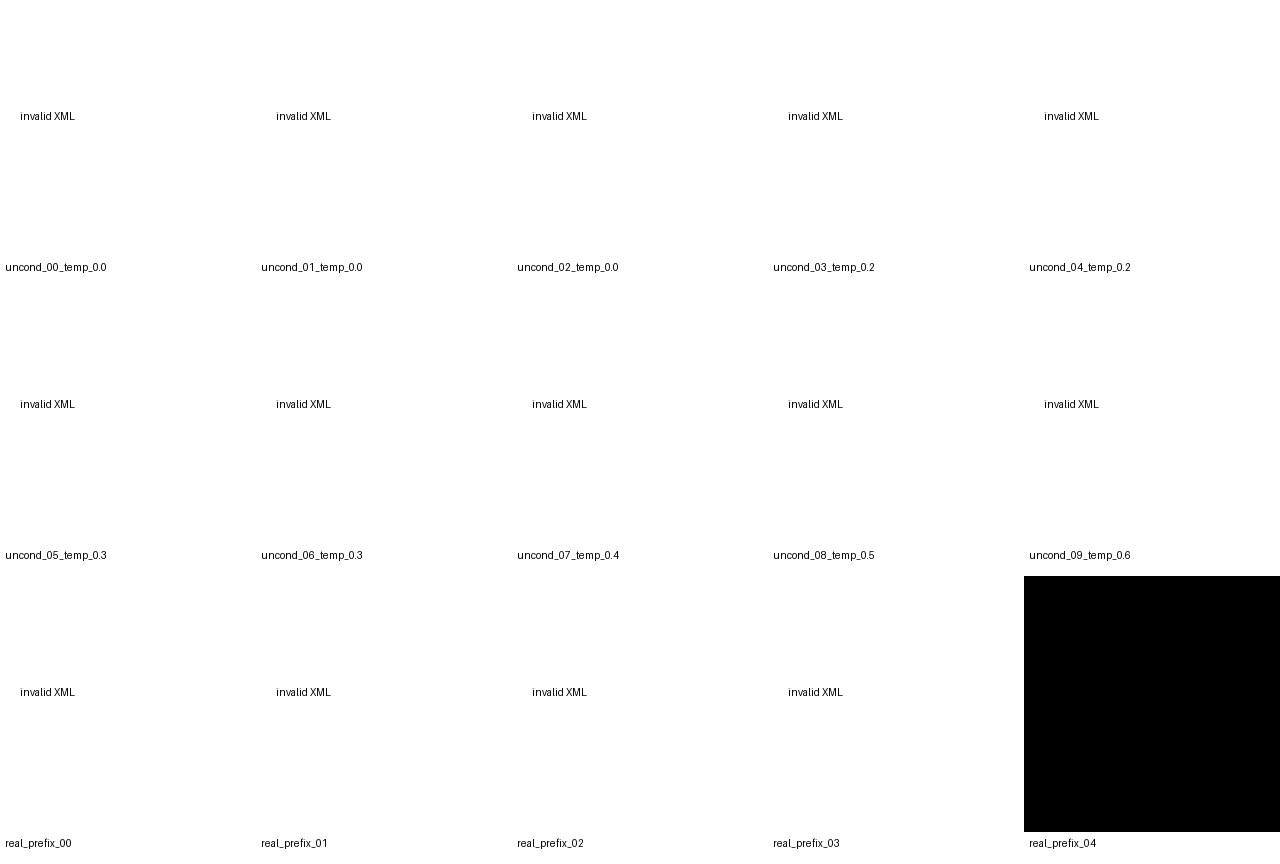

In [ ]:
import json
import pandas as pd
from IPython.display import Image, display

with open(f"{OUT_DIR_GEN_1024}/generation_summary.json") as f:
    summary = json.load(f)

print(json.dumps(summary, indent=2))

df_gen_1024 = pd.read_csv(f"{OUT_DIR_GEN_1024}/generation_metrics.csv")
display(df_gen_1024[[
    "name",
    "kind",
    "temperature",
    "char_len",
    "has_closing_svg",
    "xml_valid",
    "root_is_svg",
    "render_ok",
    "xml_error",
]])

display(Image(filename=f"{OUT_DIR_GEN_1024}/generated_grid.png"))

In [ ]:
REPO_DIR = "/content/svg-llm"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/svg_lm_project/data"

CKPT = f"{DRIVE_PROJECT_DIR}/checkpoints/generation_1024/medium_plus/best.pt"
TOKENIZER = f"{REPO_DIR}/tokenizer/svg_bpe_4096.json"
TEST_BIN = f"{DRIVE_PROJECT_DIR}/generation_dataset_1024/tokens/test.bin"
VAL_JSONL = f"{DRIVE_PROJECT_DIR}/generation_dataset_1024/cleaned/val.jsonl"
OUT_DIR_SWEEP = f"{DRIVE_PROJECT_DIR}/generation/large_sweep_generation_1024"

print(CKPT)
print(TOKENIZER)
print(TEST_BIN)
print(VAL_JSONL)
print(OUT_DIR_SWEEP)

/content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus/best.pt
/content/svg-llm/tokenizer/svg_bpe_4096.json
/content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/tokens/test.bin
/content/drive/MyDrive/svg_lm_project/data/generation_dataset_1024/cleaned/val.jsonl
/content/drive/MyDrive/svg_lm_project/data/generation/large_sweep_generation_1024


In [ ]:
%cd /content/svg-llm

!PYTHONPATH=/content/svg-llm python scripts/large_generation_sweep.py \
  --ckpt "$CKPT" \
  --tokenizer "$TOKENIZER" \
  --test_bin "$TEST_BIN" \
  --val_jsonl "$VAL_JSONL" \
  --out_dir "$OUT_DIR_SWEEP" \
  --device cuda \
  --eval_batch_size 8 \
  --max_new_tokens 1024 \
  --prefix_tokens 256 \
  --num_unconditional 200 \
  --num_real_prefix 100 \
  --max_grid_items 25

/content/svg-llm
Loaded checkpoint: /content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus/best.pt
Params: 21608832
Best val loss: 1.2538903951644897
Evaluating test loss: 100% 122/122 [00:06<00:00, 20.15it/s]
Test loss: 1.2644603311038407
Test perplexity: 3.5411811550199186
Large generation sweep: 100% 300/300 [23:47<00:00,  4.76s/it]

Overall summary:
{
  "checkpoint": "/content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus/best.pt",
  "tokenizer": "/content/svg-llm/tokenizer/svg_bpe_4096.json",
  "params": 21608832,
  "checkpoint_best_val_loss": 1.2538903951644897,
  "test_loss": 1.2644603311038407,
  "test_perplexity": 3.5411811550199186,
  "num_samples": 300,
  "num_unconditional": 200,
  "num_real_prefix": 100,
  "xml_valid_rate": 0.17666666666666667,
  "svg_root_rate": 0.17666666666666667,
  "render_rate": 0.17666666666666667,
  "closing_svg_rate": 0.17666666666666667,
  "num_valid_xml": 53,
  "num_render_ok": 53
}

Grouped

## 18. Large SVG Generation Sweep

Generate a larger batch of unconditional and real-prefix SVG samples.  
Evaluate XML validity, SVG root validity, closing-tag rate, render success, and save valid rendered samples for the report.

Overall summary:
{
  "checkpoint": "/content/drive/MyDrive/svg_lm_project/data/checkpoints/generation_1024/medium_plus/best.pt",
  "tokenizer": "/content/svg-llm/tokenizer/svg_bpe_4096.json",
  "params": 21608832,
  "checkpoint_best_val_loss": 1.2538903951644897,
  "test_loss": 1.2644603311038407,
  "test_perplexity": 3.5411811550199186,
  "num_samples": 300,
  "num_unconditional": 200,
  "num_real_prefix": 100,
  "xml_valid_rate": 0.17666666666666667,
  "svg_root_rate": 0.17666666666666667,
  "render_rate": 0.17666666666666667,
  "closing_svg_rate": 0.17666666666666667,
  "num_valid_xml": 53,
  "num_render_ok": 53
}

Grouped summary:


,kind,temperature,top_k,n,xml_valid_rate,render_rate,closing_svg_rate,mean_char_len
0,real_prefix,0.0,1,100,0.430,0.430,0.430,3705.450
1,unconditional,0.0,1,40,0.000,0.000,0.000,2309.050
2,unconditional,0.1,5,40,0.025,0.025,0.025,2547.800
3,unconditional,0.2,5,40,0.075,0.075,0.075,2350.975
4,unconditional,0.3,10,40,0.100,0.100,0.100,2564.225
5,unconditional,0.4,10,40,0.050,0.050,0.050,2786.050



Valid rendered samples: 53


,name,kind,temperature,top_k,prompt_len,char_len,has_closing_svg,xml_valid,root_is_svg,render_ok,xml_error,render_error,svg_path,png_path
0,uncond_0067,unconditional,0.2,5,67,538,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...
1,uncond_0069,unconditional,0.4,10,39,777,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...
2,uncond_0072,unconditional,0.2,5,39,510,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...
3,uncond_0076,unconditional,0.1,5,67,515,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...
4,uncond_0078,unconditional,0.3,10,39,716,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...
5,uncond_0112,unconditional,0.2,5,67,543,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...
6,uncond_0118,unconditional,0.3,10,67,1762,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...
7,uncond_0133,unconditional,0.3,10,67,503,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...
8,uncond_0154,unconditional,0.4,10,67,2408,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...
9,uncond_0168,unconditional,0.3,10,39,506,True,True,True,True,NaN,NaN,/content/drive/MyDrive/svg_lm_project/data/gen...,/content/drive/MyDrive/svg_lm_project/data/gen...


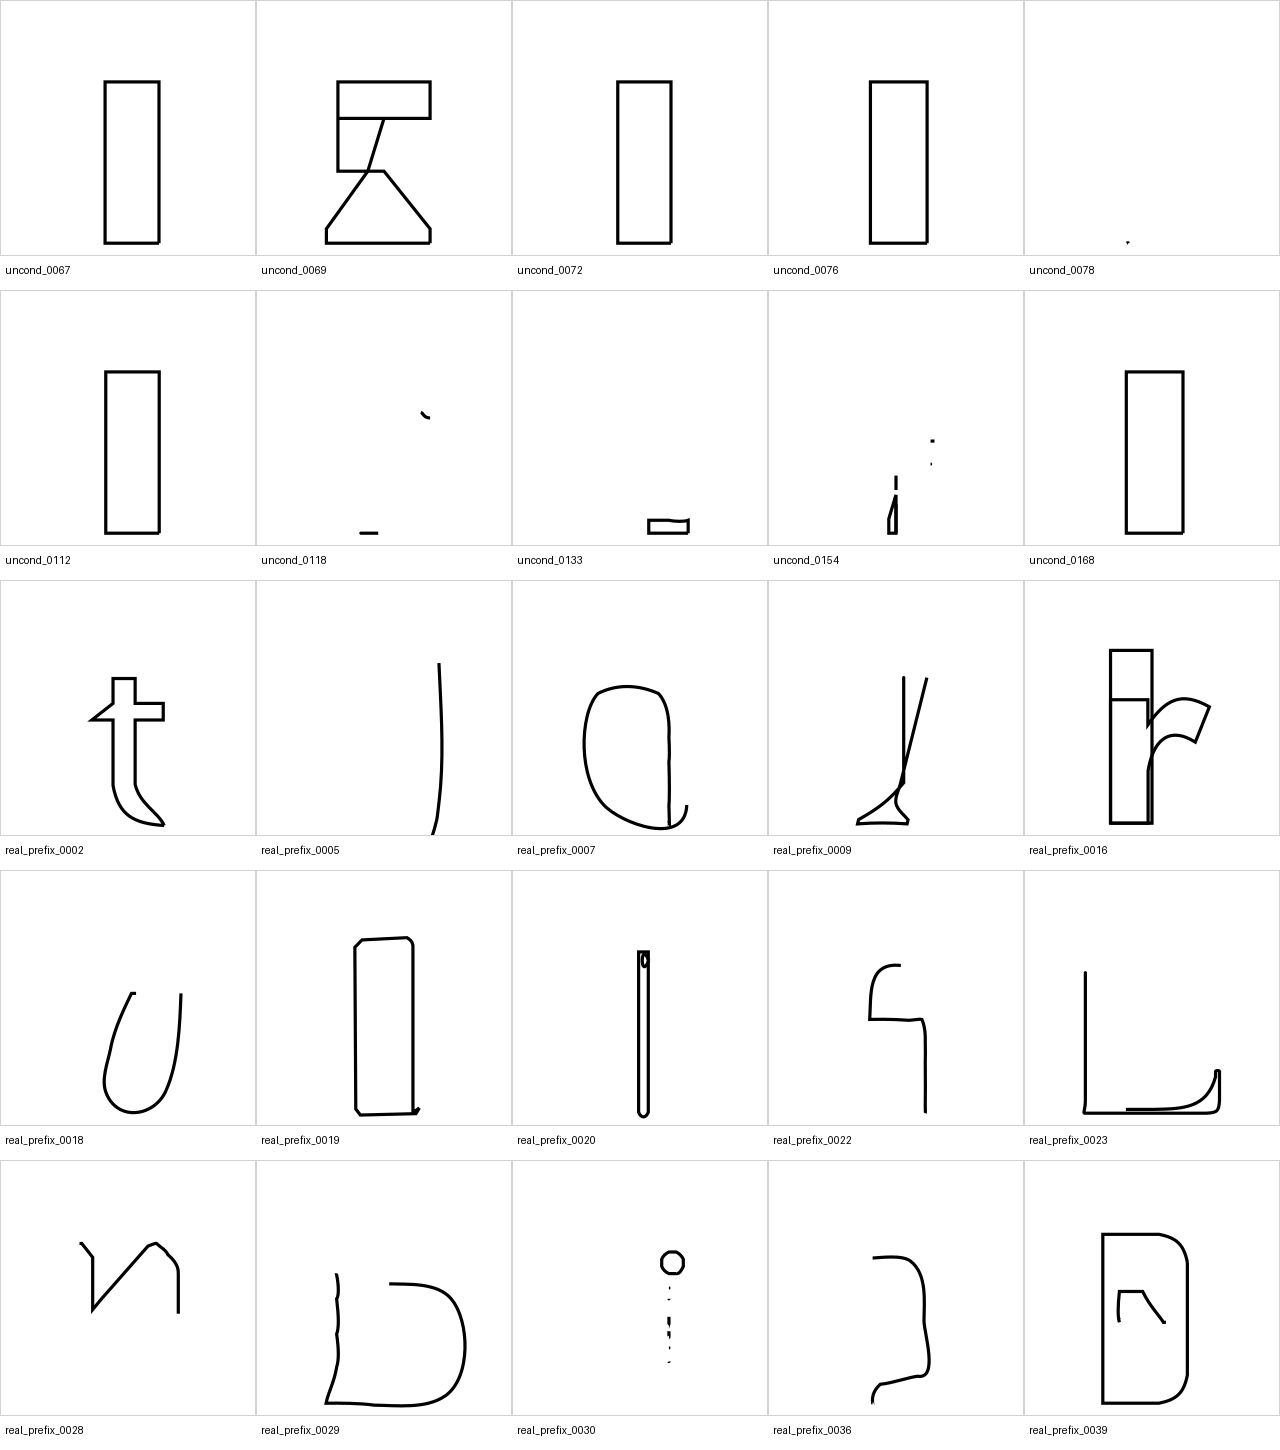

Saved white-background grid: /content/drive/MyDrive/svg_lm_project/data/generation/large_sweep_generation_1024/valid_samples_grid_white_bg.png


In [ ]:
import json
import pandas as pd
from pathlib import Path
from PIL import Image, ImageDraw
from IPython.display import Image as IPyImage, display

with open(f"{OUT_DIR_SWEEP}/generation_summary.json") as f:
    summary = json.load(f)

print("Overall summary:")
print(json.dumps(summary, indent=2))

grouped = pd.read_csv(f"{OUT_DIR_SWEEP}/generation_grouped_summary.csv")
print("\nGrouped summary:")
display(grouped)

valid_df = pd.read_csv(f"{OUT_DIR_SWEEP}/valid_samples.csv")
print("\nValid rendered samples:", len(valid_df))
display(valid_df.head(20))


def make_white_background_grid(
    valid_df,
    out_path,
    max_items=25,
    cols=5,
    cell=256,
    label_h=34,
):
    valid_df = valid_df.dropna(subset=["png_path"]).head(max_items).copy()

    if len(valid_df) == 0:
        img = Image.new("RGB", (cols * cell, cell + label_h), "white")
        draw = ImageDraw.Draw(img)
        draw.text((20, 20), "No valid rendered samples found", fill="black")
        img.save(out_path)
        return out_path

    rows = (len(valid_df) + cols - 1) // cols
    grid = Image.new("RGB", (cols * cell, rows * (cell + label_h)), "white")
    draw = ImageDraw.Draw(grid)

    for i, (_, row) in enumerate(valid_df.iterrows()):
        r = i // cols
        c = i % cols

        png_path = row["png_path"]
        name = row["name"]

        img = Image.open(png_path).convert("RGBA").resize((cell, cell))

        # Force white background under transparent SVG render
        white_bg = Image.new("RGBA", img.size, "white")
        composed = Image.alpha_composite(white_bg, img).convert("RGB")

        x = c * cell
        y = r * (cell + label_h)

        grid.paste(composed, (x, y))

        # Light border so white icons also have a visible cell boundary
        draw.rectangle(
            [x, y, x + cell - 1, y + cell - 1],
            outline="lightgray",
            width=1,
        )

        draw.text((x + 5, y + cell + 8), str(name)[:32], fill="black")

    grid.save(out_path)
    return out_path


white_grid_path = f"{OUT_DIR_SWEEP}/valid_samples_grid_white_bg.png"

make_white_background_grid(
    valid_df,
    white_grid_path,
    max_items=25,
    cols=5,
)

display(IPyImage(filename=white_grid_path))
print("Saved white-background grid:", white_grid_path)